# 05 -- One site, in depth

One site is taken apart: which days its magnetics are usable, where in time each electric line is worth
using, whether its two lines share a centre electrode, whether a tone or a spike sits in the record, and
whether a magnetic channel is worth borrowing from a neighbour. Each answer is built as a FORM -- one pass
over the same site with one thing changed -- and every form lands in the same run folder as a product
carrying the header a workbook 03 product carries.

The rule this workbook is written around: a selection of hours or days is never delivered without its
controls. Each selection carries

1. a RANDOM selection of the same size drawn without replacement from the same scored pool, under a named
   seed written into the product's header;
2. a matched-duration CONTIGUOUS selection -- windows of 2, 4, 6 and 24 h tiled from the first whole hour,
   the top windows by mean score until the kept duration matches the selection's to within one window --
   because one Aurora window at the deepest decimation level is 65,536 s, so scattered hours can never reach
   the long periods and only a contiguous comparison at the same cost decides a long-period claim;
3. the selecting statistic scored kept against dropped, with the random control exempt and expected not to
   separate;
4. the DELIVERED PRODUCT scored against its controls on the 10-1000 s bar, on smoothness and on agreement
   with the baseline at 100-1000 s.

The control sits beside the row that ships, not only beside the hypothesis. A selection whose product does
not beat its random control buys efficiency, not a different answer, and is not promoted.

Selecting on the target's own E-H coherence uses the target's own response and favours the hours where the
linear model already fits: for a dead electrode that is the truth, for a merely noisy one it can bias the
estimate towards the quiet hours. The thresholds therefore sit well below live -- 0.5, where a live line
reads above 0.85 -- and the component mask asks for a sustained run rather than a single low hour.

Seven checks state their failure criterion in bold above the cell and print a verdict below it. A check that
scores zero items prints UNJUDGED and counts as a failure. A criterion that is met is reported FAILED and is
not revised afterwards.

The site the parameter cell opens on is AusLAMP Queensland Phase 1's Q53N: its two electric lines read an
Ex-Ey coherence of 0.95-0.99 on every day of the record while its magnetometer passes the DC test against
IGRF, so the shared-centre test of section 6 has something to find and the magnetics every other section
rests on are not themselves in doubt. It has neighbours 89 and 110 km away on two sides, which is what the
fleet test, the clock test and the borrowed channel of section 8 need.

In [1]:
# ---- parameters: change these and re-run the workbook ----
SURVEY = "queensland_phase3"  # any folder under surveys/: queensland_phase2 | queensland_phase3 | victoria
SITE = "Q17"# one site; Q53N carries a shared centre and sound magnetics (see below)
RUN = "site"                  # the forms' run name; the folder is <work_root>/<SITE>/<RUN>_<stamp>
STAMP = None                  # None = the newest <RUN>_* folder if there is one, else a new stamp
BASELINE_KIND = "remote"      # the reference every form is built on: single | remote | stack | obs | stack_obs
RATES = [1]# [1] is the 1 Hz lane alone; 10 adds the notch, the spike screen and the short end
COMPONENTS = ["xy", "yx"]     # the components the masks, the windows and the hours are selected for
REDO = False                  # True remakes a form whose EDI is already in the run folder
WRITE_DECISIONS = False       # decisions are Ben's: True writes the proposed cells into decisions.csv
WORK_ROOT = None              # None = survey.yaml work_root; every product and figure lands under it


In [2]:
# ---- the method parameters: a change here changes what a form is built on ----
K_NEAREST = 2                 # the neighbours the daily magnetics test reads a day against
FLEET_NEAR_KM = 150           # the distance the fleet test reads its own pairs and its control pairs over
NEG_STRETCH = None            # None = the shifted pair alone | ("2025-10-05", "2025-10-06") a stretch of junk
DAY_THR = 0.5                 # a day is kept where its line's observatory multiple coherence reaches this
COH_BAND = (20, 200)          # the component mask's band, in s
COH_MIN = 0.5                 # ... and the running median below which an hour is masked (a live line > 0.85)
SMOOTH_H = 6                  # the running median's length, in hours
MIN_HOLE_H = 6                # a masked run shorter than this is given back
HOURS_BAND = (2, 50)          # the best-hours selecting band, in s
HOURS_FRACTION = 0.25         # the share of the candidate hours the selection keeps
CONTIG_HOURS = [2, 4, 6, 24]  # the contiguous controls, tiled from the first whole hour, in hours a window
SEED = 20260916               # the named seed every random control is drawn under
CENTRE_DAYS = 3               # the days of highest Ex-Ey coherence the residual test is read over
NOTCH_RATIO = 10              # the worst-day tone-to-sideband ratio at which a channel is notched
SPIKE_K = 30                  # the spike screen's multiple of the robust scale of the first differences
REPLACE_CHANNEL = None        # None = from the DC flags and the candidates table | "Hx" | "Hy"
LENDER = None                 # None = the nearest candidate that is not in the reference | a site name
BAR_MARGIN = 0.20             # a delivered selection must beat its control on the bar by this fraction
BAR_BAND = (10, 1000)         # the band every bar in the forms table is read over, in s
AGREE_BAND = (100, 1000)      # the band agreement with the baseline is read over, in s
DECADES = [(5, 10), (10, 100), (100, 1000), (1000, 10000)]   # the decades the tables report, in s
SHORT_BANDS = [(0.4, 0.65), (0.65, 1.4), (1.4, 4), (4, 32), (32, 1000)]  # the 10 Hz bands, in s


In [3]:
import os
for _v in ("OMP_NUM_THREADS", "MKL_NUM_THREADS", "OPENBLAS_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "3")

import json
import shutil
import time
import warnings
warnings.filterwarnings("ignore")
from datetime import datetime, timezone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

from loguru import logger as _loguru
_loguru.remove()

from auslamp_proc import agreement as AG, look as LK, products as PR, survey as SV
from auslamp_proc.process import KIND_WORD, references as REF
from auslamp_proc.process.transients import MIN_SEGMENT_S as TR_MIN_SEGMENT_S
from auslamp_proc.site import centre as CE, deliver as DL, forms as FM, masks as MK
from auslamp_proc.site import replace as RP, variants as VA
from auslamp_proc.figures import site_forms as FF
from auslamp_proc.raw import cache as CACHE

pd.set_option("display.width", 235)
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 400)

T0 = time.time()
sv = SV.load_survey(SURVEY)
if WORK_ROOT:
    sv.cfg["work_root"] = WORK_ROOT
WORK = Path(sv.cfg["work_root"])
SITES = list(sv.sites.site)
SITE_DIR = WORK / SITE
PARAMS = "kaiser20_75"
LINE = {"xy": "Ex", "yx": "Ey"}
COMP_H = {"xy": "Hy", "yx": "Hx"}
WRITTEN = []
FORM_ROWS = []
_tfs = {}


def run_dir():
    """The run folder: the newest <RUN>_* where STAMP is None and one exists, else <RUN>_<stamp>.

    A form already in the folder is reported as `exists` and not remade, so the workbook can be re-run at a
    second rate without repeating the first.
    """
    if STAMP:
        return SITE_DIR / ("%s_%s" % (RUN, STAMP))
    old = sorted(SITE_DIR.glob("%s_*" % RUN))
    return old[-1] if old else SITE_DIR / ("%s_%s" % (RUN, datetime.now(timezone.utc).strftime("%Y%m%d_%H%M")))


OUT = run_dir()
OUT.mkdir(parents=True, exist_ok=True)


def form(name, **kw):
    """One form, recorded in FORM_ROWS. Every keyword is auslamp_proc.site.forms.run_form's."""
    kw.setdefault("kind", BASELINE_KIND)
    kw.setdefault("rate", 1)
    kw.setdefault("params", PARAMS)
    kw.setdefault("redo", REDO)
    row = FM.run_form(sv, SITE, name, OUT, **kw)
    FORM_ROWS.append(row)
    return row


def read(path):
    """One transfer function, cached: a page, a table and a verdict ask for the same file."""
    path = str(path)
    if path not in _tfs:
        _tfs[path] = PR.read_tf(path)
    return _tfs[path]


def rows_by_form():
    return {r["form"]: r for r in FORM_ROWS}


def made_product(name):
    """The product of one form where it was made and is on disk, else None."""
    r = rows_by_form().get(name, {})
    if r.get("status") in ("made", "exists") and Path(str(r.get("product") or "")).exists():
        return r
    return None


def baseline_path():
    """Workbook 03's product of the chosen kind at 1 Hz, copied into this run folder as the `whole` form.

    The baseline is not re-estimated: it is the file workbook 04 read, under the name the forms table uses,
    so every form is read against the product the earlier workbooks left.
    """
    led = PR.ledger(WORK)
    rows = led[(led.site == SITE) & (led.kind == BASELINE_KIND) & (led.rate_hz == 1.0)]
    if not len(rows):
        return None, "runs.csv names no %s product of %s at 1 Hz" % (BASELINE_KIND, SITE)
    r = rows.sort_values("stamp").iloc[-1]
    src = PR.product_path(WORK, SITE, r.run, r.stamp, r.kind, r.rate_hz, r.params)
    if not src.exists():
        return None, "%s is not on disk" % src
    dst = OUT / FM.product_name(SITE, "whole", BASELINE_KIND, 1, PARAMS)
    if not dst.exists():
        shutil.copyfile(src, dst)
    return dst, "copied from %s" % src.parent.name


BASE, BASE_WHY = baseline_path()
FORM_ROWS.append(dict(site=SITE, form="whole", kind=BASELINE_KIND, rate_hz=1.0, params=PARAMS,
                      product=str(BASE) if BASE else "", controls="", criterion="the baseline itself",
                      seed=None, status=("exists" if BASE else "FAILED"),
                      error=("" if BASE else BASE_WHY), days=None, n_runs=None, seconds=None))

ELINES = CE.read_elines(sv, SITE)
DC = pd.read_csv(SITE_DIR / "dc.csv") if (SITE_DIR / "dc.csv").exists() else pd.DataFrame()

print("survey       %s" % sv.cfg["name"])
print("site         %s -- %s" % (SITE, sv.site(SITE).notes or "no note in sites.csv"))
print("work root    %s" % WORK)
print("run folder   %s" % OUT)
print("baseline     %s (%s)" % (Path(BASE).name if BASE else "NONE", BASE_WHY))
print("rates        %s Hz; components %s" % (", ".join(str(r) for r in RATES), ", ".join(COMPONENTS)))
print("seed         %d, used by every random control in this workbook" % SEED)


survey       queensland_phase3
site         Q17 -- resistance rows relabelled N-G/W-G, agrees; clay soil hard digging; silver electrodes
work root    E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3
run folder   E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022
baseline     Q17_whole_remote_1hz_kaiser20_75.edi (copied from first_20260916_2015)
rates        1 Hz; components xy, yx
seed         20260916, used by every random control in this workbook


## 1. The site as workbooks 02 to 04 left it

The record figure, the magnetometer DC test and the per-day state of the two electric lines are workbook 02's;
the products and their agreement are workbook 03's and 04's. Nothing here is recomputed. What the three
tables say is what selects the methods below: a magnetometer that fails the DC test sends the work to section
8, a line that dies mid-record sends it to section 4, and two lines carrying one voltage send it to section
6.

In [4]:
print("the magnetometer against IGRF (workbook 02)")
print(DC.to_string(index=False) if len(DC) else "no dc.csv: run workbook 02 over this site")
print()
keep_cols = ("site", "days_scored", "Ex_sound", "Ex_weak", "Ex_common", "Ex_dead",
             "Ey_sound", "Ey_weak", "Ey_common", "Ey_dead", "both_sound_days")
summary = pd.DataFrame([{k: v for k, v in LK.eline_summary(ELINES, SITE).items() if k in keep_cols}])
print("the two electric lines by day (workbook 02)")
print(summary.to_string(index=False))
print()
print("Ex-Ey coherence over the record: median %.3f, maximum %.3f over %d scored day(s)"
      % (float(np.nanmedian(ELINES.coh_Ex_Ey)), float(np.nanmax(ELINES.coh_Ex_Ey)),
         int(ELINES.coh_Ex_Ey.notna().sum())))
for name in ("01_record.png", "02_coherence_bands.png"):
    p = SITE_DIR / name
    if p.exists():
        display(Image(filename=str(p)))


the magnetometer against IGRF (workbook 02)
     Bx     By       Bz       H       F  igrf_X  igrf_Y   igrf_Z  igrf_H  igrf_F  igrf_D  Bx_over_X  Bz_over_Z  H_over_Higrf  F_over_Figrf  angle_deg  tilt_deg  flags verdict site  days
32229.0 1037.1 -37832.2 32245.7 49709.8 31898.8  3368.9 -38337.6 32076.2 49986.5    6.03     1.0104     0.9868        1.0053        0.9945       1.84      0.52    NaN    PASS  Q17 34.03

the two electric lines by day (workbook 02)
site  days_scored  Ex_sound  Ex_weak  Ex_common  Ex_dead  Ey_sound  Ey_weak  Ey_common  Ey_dead  both_sound_days
 Q17           34         0       26          8        0        12       21          1        0                0

Ex-Ey coherence over the record: median 0.518, maximum 0.708 over 34 scored day(s)


### What this workbook will try, and why

The methods are keyed to the three tables above: a common-mode signature on the two lines calls for the
shared-centre test of section 6, a magnetic flag or a channel reading low against its neighbours calls for
the replacement of section 8, and a line that dies mid-record calls for the window of section 4. The
selections of sections 3 and 5 apply wherever a line is alive but noisy.

In [5]:
common = float(np.nanmedian(ELINES.coh_Ex_Ey)) if len(ELINES) else np.nan
# DC["flags"], not DC.flags: a DataFrame carries a `flags` attribute of its own and attribute access
# reaches that object rather than the column
flags = str(DC["flags"].iloc[0]) if len(DC) and "flags" in DC.columns else ""
dead = {c: int((ELINES["%s_state" % LINE[c]] == "dead").sum()) if len(ELINES) else 0 for c in COMPONENTS}
plan = [
    dict(section="2 the magnetics by day", applies=True, why="every later test rests on Hx and Hy"),
    dict(section="3 the quality map and the day masks", applies=True,
         why="where in time each line follows the field"),
    dict(section="4 windows", applies=bool(len(ELINES)),
         why="a line dead on %s of %d day(s)" % ("/".join(str(dead[c]) for c in COMPONENTS), len(ELINES))),
    dict(section="5 best hours", applies=True, why="a line alive but noisy"),
    dict(section="6 the shared centre", applies=bool(np.isfinite(common) and common >= 0.5),
         why="median Ex-Ey coherence %.2f" % common),
    dict(section="7 the notch and the spike screen", applies=10 in RATES,
         why="the census reads the 10 Hz cache"),
    dict(section="8 replacement magnetics", applies=True, why="DC flags: %s" % (flags or "none")),
]
print(pd.DataFrame(plan).to_string(index=False))


                            section  applies                                       why
             2 the magnetics by day     True       every later test rests on Hx and Hy
3 the quality map and the day masks     True where in time each line follows the field
                          4 windows     True           a line dead on 0/0 of 34 day(s)
                       5 best hours     True                    a line alive but noisy
                6 the shared centre     True               median Ex-Ey coherence 0.52
   7 the notch and the spike screen    False          the census reads the 10 Hz cache
            8 replacement magnetics     True                             DC flags: nan


## 2. The magnetics by day

Three tests, each with its control.

The daily test reads each UTC day's total field against IGRF and the fluctuation of Hx and Hz -- the standard
deviation after a 3,000 s high-pass -- against the median of the K_NEAREST sites recording that day. A day is
sound where the field is within 5 per cent of IGRF and both fluctuations sit within a factor 3 of the
neighbours'. Without a neighbour that day only the field is judged and the row says so.

The fleet test takes one stretch and scores the 100-1000 s Hx-Hx and Hy-Hy coherence of every pair of the
site and the sites covering it. Its POSITIVE limb reads the site's median against the sites within
FLEET_NEAR_KM against the CONTROL PAIRS at the same distances: a site coherent with the fleet the way its
neighbours are with each other is a site whose magnetics can be used. A site incoherent with every other
site -- a median Hx coherence under 0.3 -- is named and dropped from the control, because a dead sensor or a
clock hours out is not a control.

Its NEGATIVE limb is the SHIFTED PAIR: the same stretch, the same estimator, the site's Hx against each
neighbour's Hx taken 12 h later (and Hy likewise), medianed over the pairs, which must read under 0.3. That
is a change of criterion and not a relaxation of one (Ben, 2026-09-17). The criterion used until then was a
stretch of the site's own junk magnetics, and a stretch of junk does not exist at a sound site: written that
way the criterion fails by construction wherever the magnetics are good, and the number it reports is the
coherence of a perfectly good day, which says nothing about the site. The shifted pair exists at every site
and tests what the criterion is for -- whether the estimator can tell a coherent pair from an incoherent one
over THIS stretch, in THIS band, on THESE records. A stretch of junk is still accepted as NEG_STRETCH and is
reported beside the shifted control where one is given.

The clock test reads the lag of the peak cross-correlation of the despiked Hx against a reference site over a
+-12 h search, and refines the peak to a fraction of a sample with a parabola through its two neighbours. The
series correlated is the 5-20 s BAND-PASSED record and not the 3,000 s high-passed one the coherence tests
use -- a change of criterion and not a relaxation of one (Ben, 2026-09-17). The high-pass leaves the daily
variation in, and the daily variation is a half-day sinusoid: correlated against a neighbour it peaks at the
edge of a +-12 h search as readily as at zero. At Q17 two days survived the earlier rule at +-30,000 s with
peak correlations of 0.52-0.62 against a floor of 0.3-0.4 on every other lag of the same day, while the
campaign measured that same clock at +0.4 s on this band. The search window stays at +-12 h so an hour-scale
offset is still found.

Three guards follow from it, and a day is counted only where all of them hold with the field test: the peak
correlation reaches 0.5, the peak stands at least 1.5 times the median correlation over that day's other
lags, and the peak is not within 5 per cent of the search edge. Fewer than 5 counted days leaves the clock
UNJUDGED and no median is reported, because a median of two edge hits is a number with no measurement behind
it.

**This check fails if the shifted-pair control reads a 100-1000 s coherence of 0.3 or more on either
horizontal channel or could not be scored, if the site's own median falls below 0.8 of the control pairs' on
either channel, if fewer than 5 days could be timed, or if the clock lag's median exceeds 10 s.**

In [6]:
dm = MK.daily_magnetics_test(sv, SITE, K_NEAREST, SITES)
print("neighbours: %s" % ", ".join(dm.attrs.get("neighbours", [])) or "none overlapping")
print(dm.round(3).to_string(index=False))
judged = dm[dm.judged]
print()
print("%d of %d day(s) sound, %d judged against a neighbour"
      % (int(dm.sound.sum()), len(dm), int(dm.judged.sum())))


neighbours: Q21 (67 km), Q22 (149 km)
       day  F_ratio   hx_std   hz_std  n_neighbours  nb_F_ratio  nb_hx_std  nb_hz_std  sound  judged                                     reason
2026-06-14    0.995  263.333  327.589             2       0.995      2.705      3.285  False    True Hx 263.3 against 2.7, Hz 327.6 against 3.3
2026-06-15    0.995    0.343    0.190             2       0.995      3.610      3.249  False    True     Hx 0.3 against 3.6, Hz 0.2 against 3.2
2026-06-16    0.994    0.547    0.214             2       0.995      2.732      2.996  False    True     Hx 0.5 against 2.7, Hz 0.2 against 3.0
2026-06-17    0.994    1.046    0.229             2       0.995      3.145      3.019  False    True     Hx 1.0 against 3.1, Hz 0.2 against 3.0
2026-06-18    0.995    0.433    0.226             2       0.995      3.154      3.186  False    True     Hx 0.4 against 3.2, Hz 0.2 against 3.2
2026-06-19    0.994    0.493    0.219             2       0.995      2.786      2.919  False    Tr

The daily test as three strips, one row per day: the field against IGRF with its 5 per cent
band, and the Hx and Hz fluctuation ratios against the neighbours' median with the factor-3 band. A day
outside any band is red; a day with no neighbour is grey and judged on the field alone. What to look for is
a run of red days at one end of the record -- the transit hours, or a sensor that moved -- rather than red
days scattered through it, which is a neighbour problem and not the site's.

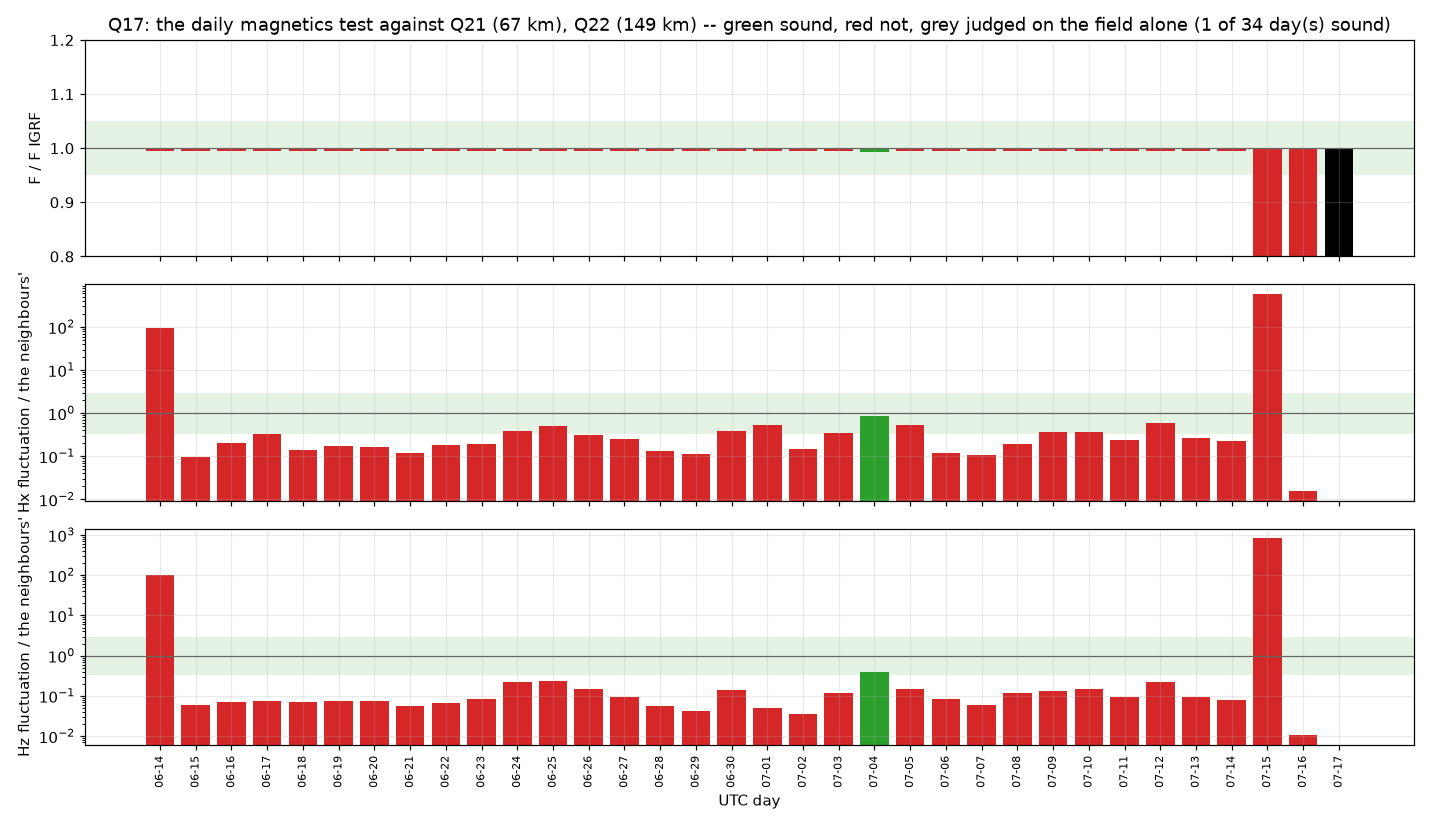

In [7]:
fig = FF.daily_magnetics(dm, SITE, OUT / "06_daily_magnetics.png",
                        neighbours=dm.attrs.get("neighbours", []))
WRITTEN.append(OUT / "06_daily_magnetics.png")
display(Image(filename=str(OUT / "06_daily_magnetics.png")))


In [8]:
# the stretch the fleet test reads: the first two sound days. NEG_STRETCH stays available for a stretch
# of junk magnetics, and the shifted pair is the control the criterion is written on
t0_rec, n_rec = MK.span(sv, SITE, 1)
day_start = {r.day: int(pd.Timestamp(r.day, tz="UTC").timestamp()) for r in dm.itertuples()}
sound = [r.day for r in dm.itertuples() if r.sound and r.judged]
# the sound day nearest the middle of the record, not the first: the first sound day sits beside the transit
# hours, and the shifted control needs the neighbours' records to reach 12 h either side of the stretch
MIDDLE = sound[len(sound) // 2] if sound else None
FLEET_STRETCH = ((day_start[MIDDLE], day_start[MIDDLE] + 2 * 86400) if MIDDLE
                 else (t0_rec + 86400, t0_rec + 3 * 86400))
print("fleet stretch  %s .. %s" % (pd.Timestamp(FLEET_STRETCH[0], unit="s"),
                                   pd.Timestamp(FLEET_STRETCH[1], unit="s")))
print("shifted control: the same stretch of each neighbour taken %g h later" % (MK.SHIFT_CONTROL_S / 3600))
NEG = (tuple(int(pd.Timestamp(x, tz="UTC").timestamp()) for x in NEG_STRETCH) if NEG_STRETCH else None)
print("NEG_STRETCH    %s" % (NEG_STRETCH or "none: no stretch of junk magnetics was named"))
ft = MK.fleet_test(sv, SITE, FLEET_STRETCH[0], FLEET_STRETCH[1], negative=NEG,
                   near_km=FLEET_NEAR_KM, sites=SITES)
print(ft["table"].round(3).to_string(index=False) if len(ft["table"]) else "no pair scored")
print()
print("%s: Hx %.2f Hy %.2f over %d pair(s) | control pairs Hx %.2f Hy %.2f over %d pair(s)%s"
      % (SITE, ft["site_hx"], ft["site_hy"], ft["n_pairs_site"], ft["control_hx"], ft["control_hy"],
         ft["n_pairs_control"],
         ("; dropped from the control as incoherent with the fleet: " + " ".join(ft["junk"]))
         if ft["junk"] else ""))
if len(ft.get("shifted_table", [])):
    print()
    print("the shifted pair, %g h, one row per neighbour" % (MK.SHIFT_CONTROL_S / 3600))
    print(ft["shifted_table"].round(3).to_string(index=False))
print("shifted control: Hx %.2f Hy %.2f over %d pair(s), and it must read under %.1f"
      % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX))
if NEG_STRETCH:
    print("NEG_STRETCH:     Hx %.2f Hy %.2f (a reading beside the shifted control)"
          % (ft["negative_hx"], ft["negative_hy"]))


fleet stretch  2026-07-04 00:00:00 .. 2026-07-06 00:00:00
shifted control: the same stretch of each neighbour taken 12 h later
NEG_STRETCH    none: no stretch of junk magnetics was named


  a   b      km    Hx    Hy
Q17 Q21  67.325 0.948 0.759
Q32 Q33  76.834 0.989 0.964
Q31 Q38  97.228 0.998 0.989
Q27 Q31 105.331 0.991 0.984
Q28 Q33 116.380 0.997 0.989
Q21 Q22 121.164 0.968 0.843
Q31 Q32 133.903 0.994 0.990
Q28 Q32 136.762 0.994 0.988
Q17 Q22 149.156 0.964 0.657
Q22 Q27 166.641 0.991 0.923
Q27 Q32 167.102 0.993 0.977
Q32 Q38 169.164 0.996 0.980
Q27 Q28 196.208 0.996 0.991
Q27 Q38 202.557 0.994 0.995
Q31 Q33 210.671 0.984 0.969
Q27 Q33 230.018 0.994 0.989
Q31 Q28 232.976 0.991 0.984
Q38 Q33 237.790 0.989 0.981
Q21 Q27 255.982 0.969 0.960
Q22 Q31 262.809 0.990 0.957
Q28 Q38 298.079 0.994 0.986
Q22 Q28 304.931 0.990 0.941
Q17 Q27 305.895 0.975 0.750
Q22 Q32 327.291 0.989 0.969
Q21 Q31 329.693 0.968 0.925
Q22 Q38 356.011 0.991 0.928
Q22 Q33 378.281 0.984 0.897
Q17 Q31 388.375 0.953 0.719
Q21 Q38 409.751 0.967 0.950
Q21 Q28 421.257 0.968 0.933
Q21 Q32 423.083 0.967 0.903
Q17 Q28 453.305 0.976 0.725
Q17 Q32 471.673 0.959 0.700
Q17 Q38 472.260 0.958 0.736
Q21 Q33 483.061 0.96

One bar per pair of the fleet table, the site's own pairs first and the control pairs behind,
with the shifted pair of each neighbour drawn beside it. What to look for is the shifted bars sitting on the
floor while the unshifted ones stand: that gap is the whole content of the test, and a site whose own bars
sit down with the shifted ones has magnetics the fleet does not see.

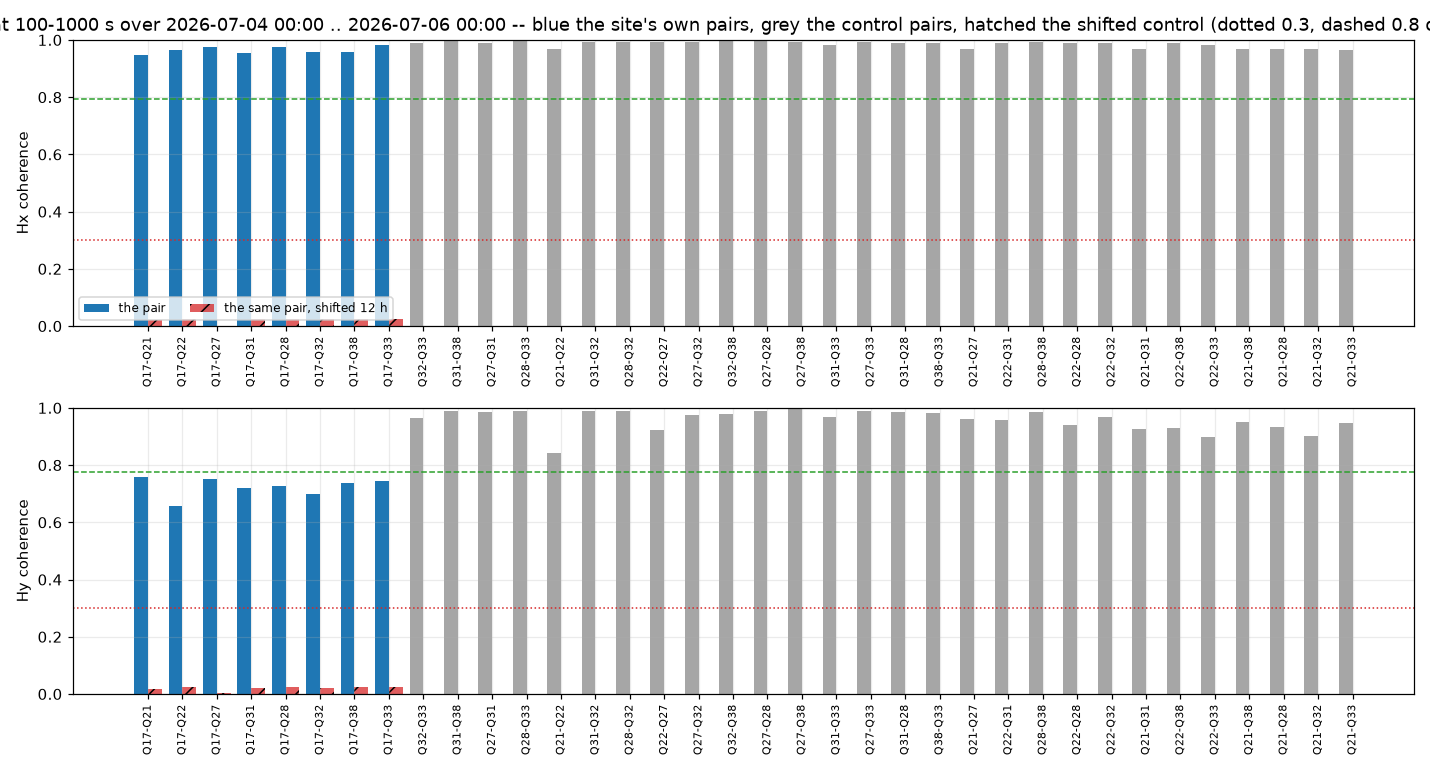

In [9]:
fig = FF.fleet_bars(ft, SITE, OUT / "07_fleet.png", near_km=FLEET_NEAR_KM,
                    floor=MK.NEGATIVE_MAX)
WRITTEN.append(OUT / "07_fleet.png")
display(Image(filename=str(OUT / "07_fleet.png")))


the clock against Q22 (149 km) on the 5-20 s band, searched to +-12 h
       day     lag_s  peak_r  peak_over_floor  r_at_zero  edge  F_ratio  counted                                                     reason
2026-06-14      8.05   0.121            18.17     -0.137 False    0.995    False                                             peak under 0.5
2026-06-15 -14160.21   0.045             5.82     -0.010 False    0.995    False                                             peak under 0.5
2026-06-16  33754.48   0.053             6.46     -0.006 False    0.994    False                                             peak under 0.5
2026-06-17  42600.06   0.051             6.32     -0.018  True    0.994    False peak under 0.5; an edge hit at 42600 s of a 43200 s search
2026-06-18   9498.23   0.048             5.92     -0.019 False    0.995    False                                             peak under 0.5
2026-06-19     -8.59   0.105            12.20     -0.116 False    0.994    False          

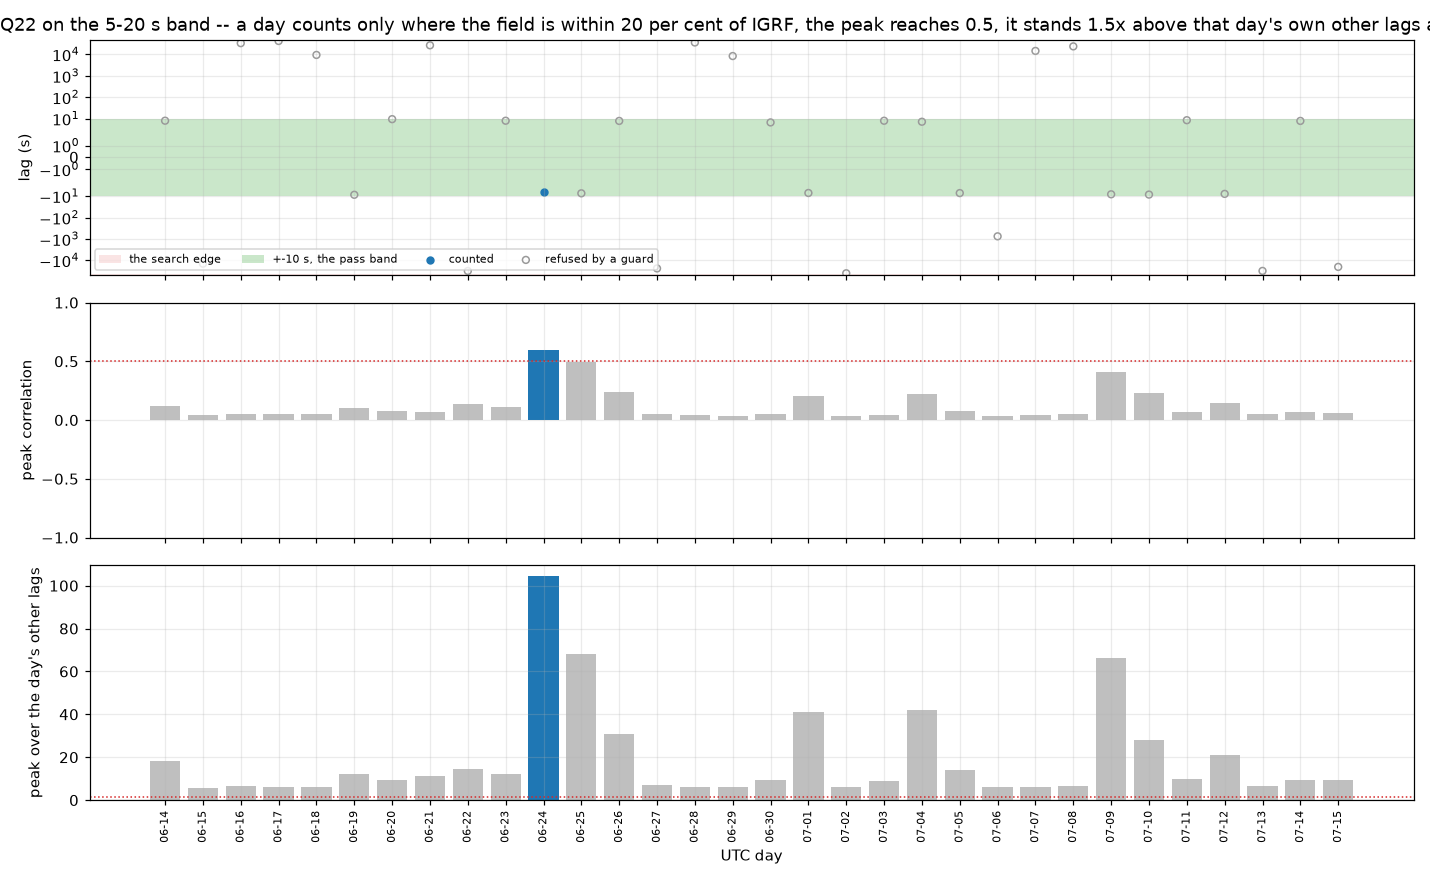

In [10]:
ck = MK.clock_test(sv, SITE, sites=SITES)
print("the clock against %s (%.0f km) on the %g-%g s band, searched to +-%g h"
      % (ck["ref"], ck.get("km", np.nan), MK.CLOCK_BAND_S[0], MK.CLOCK_BAND_S[1],
         MK.CLOCK_MAXLAG_S / 3600))
if len(ck["table"]):
    print(ck["table"].round(3).to_string(index=False))
print("%d day(s) counted of %d; %s"
      % (ck["n_days"], len(ck["table"]),
         ("median lag %+.2f s" % ck["median_lag_s"]) if ck["judged"]
         else "UNJUDGED, and no median is reported: %s" % ck["reason"]))
fig = FF.clock_lags(ck, SITE, OUT / "08_clock.png", pass_s=MK.CLOCK_PASS_S,
                    edge_fraction=MK.CLOCK_EDGE_FRACTION, peak_ratio=MK.CLOCK_PEAK_RATIO,
                    maxlag_s=MK.CLOCK_MAXLAG_S)
WRITTEN.append(OUT / "08_clock.png")
display(Image(filename=str(OUT / "08_clock.png")))


In [11]:
fail = []
if not ft.get("shifted_judged"):
    fail.append("the shifted-pair control was not scored (no neighbour's record reaches %g h either side of "
                "the stretch), so the fleet test was not shown able to fail" % (MK.SHIFT_CONTROL_S / 3600))
elif max(ft["shifted_hx"], ft["shifted_hy"]) >= MK.NEGATIVE_MAX:
    fail.append("the shifted-pair control reads Hx %.2f Hy %.2f over %d pair(s), at or above %.1f"
                % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX))
if not ft.get("positive_ok"):
    fail.append("the site reads Hx %.2f Hy %.2f against the control pairs' %.2f and %.2f, below %.1f of them"
                % (ft["site_hx"], ft["site_hy"], ft["control_hx"], ft["control_hy"],
                   MK.FLEET_CONTROL_FRACTION))
if not ck["judged"]:
    fail.append("UNJUDGED on the clock against %s: %s" % (ck["ref"], ck["reason"]))
elif abs(ck["median_lag_s"]) > MK.CLOCK_PASS_S:
    fail.append("the clock lag's median is %+.2f s over %d day(s), beyond %.0f s"
                % (ck["median_lag_s"], ck["n_days"], MK.CLOCK_PASS_S))
if fail:
    print("VERDICT: FAIL -- %s; for the record the shifted-pair control reads Hx %.2f Hy %.2f over %d "
          "pair(s) and the clock counted %d day(s) of %d on the %g-%g s band"
          % ("; ".join(fail), ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], ck["n_days"],
             len(ck["table"]), MK.CLOCK_BAND_S[0], MK.CLOCK_BAND_S[1]))
else:
    print("VERDICT: PASS -- the shifted-pair control reads Hx %.2f Hy %.2f over %d pair(s), both under "
          "%.1f, where the same pairs unshifted read Hx %.2f Hy %.2f; over the sound stretch the site reads "
          "Hx %.2f Hy %.2f against the control pairs' %.2f and %.2f, above %.1f of them; the clock lag's "
          "median is %+.2f s over %d counted day(s) on the 5-20 s band, within %.0f s%s"
          % (ft["shifted_hx"], ft["shifted_hy"], ft["n_shifted"], MK.NEGATIVE_MAX, ft["site_hx"],
             ft["site_hy"], ft["site_hx"], ft["site_hy"], ft["control_hx"], ft["control_hy"],
             MK.FLEET_CONTROL_FRACTION, ck["median_lag_s"], ck["n_days"], MK.CLOCK_PASS_S,
             ("; NEG_STRETCH reads Hx %.2f Hy %.2f as a reading beside it"
              % (ft["negative_hx"], ft["negative_hy"])) if NEG_STRETCH else ""))


VERDICT: FAIL -- the site reads Hx 0.96 Hy 0.71 against the control pairs' 0.99 and 0.99, below 0.8 of them; UNJUDGED on the clock against Q22: only 1 day(s) of 32 carry a peak that is above 0.5, stands 1.5x above the day's own other lags and is not within 5 per cent of the 12 h search edge; for the record the shifted-pair control reads Hx 0.02 Hy 0.02 over 8 pair(s) and the clock counted 1 day(s) of 32 on the 5-20 s band


## 3. The quality map and the day masks

The quality map is where in time each electric line follows the magnetic field. Three scales, each with the
statistic the scale can carry: the hourly 4-50 s coherence of each line with the H it couples to, the daily
50-1000 s MULTIPLE coherence of each line with the local pair and with the observatory pair, and one
1000-10000 s number on the whole record decimated to 0.1 Hz. The multiple coherence is bias-corrected --
g2c = (g2 - p/nu) / (1 - p/nu) with p = 2 predictors and nu = 0.82 times the number of segments -- because an
estimate from few segments saturates at 1 or sits on the bias floor, which is what an uncorrected hourly
estimate over 50-1000 s reads at every site.

What the number is, and what it is not. It is the fraction of the electric line's power the magnetic field
explains, so it measures LOCAL ELECTRIC NOISE. A low value does not mean the component cannot be measured: a
remote reference beats the noise the target and the reference do not share, which is why the sites with a
noisy shared centre sit at the bottom of this table and still deliver products. Nor does a high value mean
the row is right: a site whose second line repeats the first has the highest coherence in a survey and an
unusable yx row, which is a geometry fault that coherence with the magnetic field cannot see.

The day mask keeps the whole days whose OBSERVATORY multiple coherence reaches DAY_THR; those columns carry
no local magnetic noise, which is why the mask is taken on them. Its control keeps the same number of days
drawn without replacement from the same pool of scored days under the seed printed below.

**This check fails if any mask lacks its control, if a control differs in size from its selection, if a mask
keeps too few days to be scored at all, or if a PROMOTED mask does not beat its control on the 10-1000 s bar
by at least 20 per cent.** Promotion is the reading, not the criterion (Ben, 2026-09-17): the wording used
until then conflated "not promoted" with "failed", so a mask that honestly bought nothing was recorded as a
defect of the workbook. A mask that does not beat its control buys efficiency and not a different answer, is
printed as such, and is not carried into the forms table as a candidate; the check is on whether every
selection has a control of the right size, whether anything was scored at all, and whether the promotions the
section makes agree with the bar they are made on.

the quality map in 17 s: 816 hour(s), 34 day(s), observatory CTA
site  hours  days observatory  Ex_hourly_med  Ex_hourly_over_0p5  Ey_hourly_med  Ey_hourly_over_0p5  Ex_local_med  Ex_local_days_over_0p5  Ey_local_med  Ey_local_days_over_0p5  Ex_obs_med  Ex_obs_days_over_0p5  Ey_obs_med  Ey_obs_days_over_0p5  Ex_vlong  Ey_vlong
 Q17    816    34         CTA            0.0               0.002            0.0               0.051          0.18                   0.059         0.914                   0.912       0.739                 0.824       0.847                 0.853     0.959     0.963


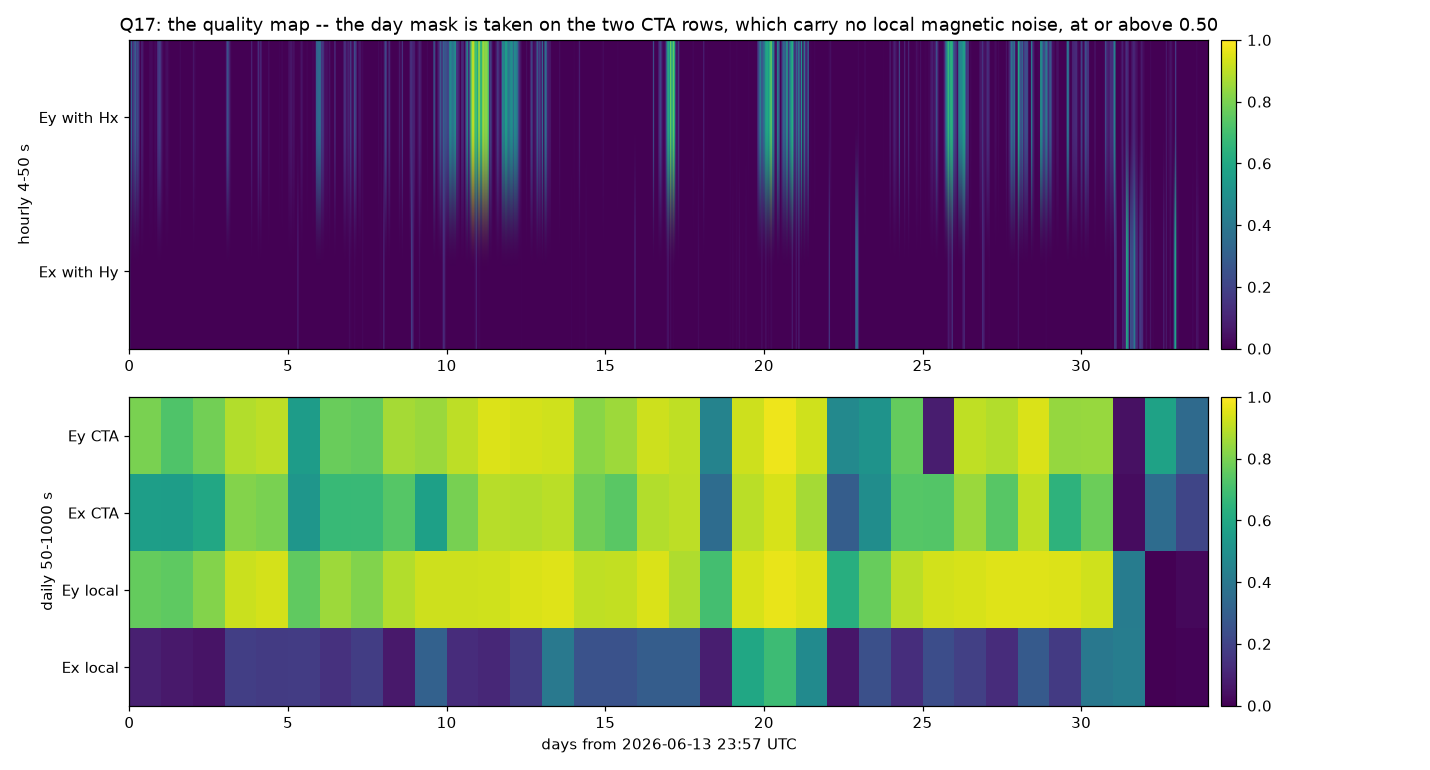

In [12]:
t = time.time()
QM = MK.quality_map(sv, SITE)
print("the quality map in %.0f s: %d hour(s), %d day(s), observatory %s"
      % (time.time() - t, QM["hours"], QM["n_days"], QM["observatory"]))
print(pd.DataFrame([MK.quality_row(QM)]).round(3).to_string(index=False))
fig = FF.quality_images(QM, SITE, OUT / "09_quality_map.png", thr=DAY_THR)
WRITTEN.append(OUT / "09_quality_map.png")
display(Image(filename=str(OUT / "09_quality_map.png")))


In [13]:
DAY_MASKS, rows = {}, []
for comp in COMPONENTS:
    keep, ctrl, info = MK.day_mask(QM, comp, DAY_THR, SEED)
    DAY_MASKS[comp] = (keep, ctrl, info)
    rows.append({k: v for k, v in info.items() if k not in ("kept_days", "control_days")})
print("the day mask per component, on the %s columns, threshold %.2f, seed %d"
      % (QM["observatory"], DAY_THR, SEED))
print(pd.DataFrame(rows).round(3).to_string(index=False))
for comp in COMPONENTS:
    print("   %s kept    %s" % (comp, DAY_MASKS[comp][2]["kept_days"][:110]))
    print("   %s control %s" % (comp, DAY_MASKS[comp][2]["control_days"][:110]))


the day mask per component, on the CTA columns, threshold 0.50, seed 20260916
component      column  threshold     seed  days_scored  days_total  days_kept  days_control  median_kept  median_dropped                                            pool  enough
       xy observatory        0.5 20260916           34          34         28            28        0.779           0.323 the days the map scored, the selection included    True
       yx observatory        0.5 20260916           34          34         29            29        0.864           0.345 the days the map scored, the selection included    True
   xy kept    2026-06-13 2026-06-14 2026-06-15 2026-06-16 2026-06-17 2026-06-18 2026-06-19 2026-06-20 2026-06-21 2026-06-22 
   xy control 2026-06-13 2026-06-14 2026-06-15 2026-06-16 2026-06-17 2026-06-18 2026-06-19 2026-06-20 2026-06-23 2026-06-24 
   yx kept    2026-06-13 2026-06-14 2026-06-15 2026-06-16 2026-06-17 2026-06-18 2026-06-19 2026-06-20 2026-06-21 2026-06-22 
   yx control 20

The record with the masks drawn on it: the kept days of each component as a solid span in its own
colour, the random control of the same size hatched. What to look for is whether the kept days sit together
at one end of the record -- in which case the mask is a window in disguise and the contiguous comparison of
section 5 is the one to read -- or scattered through it, and whether the control's days look any different to
the eye than the selection's.

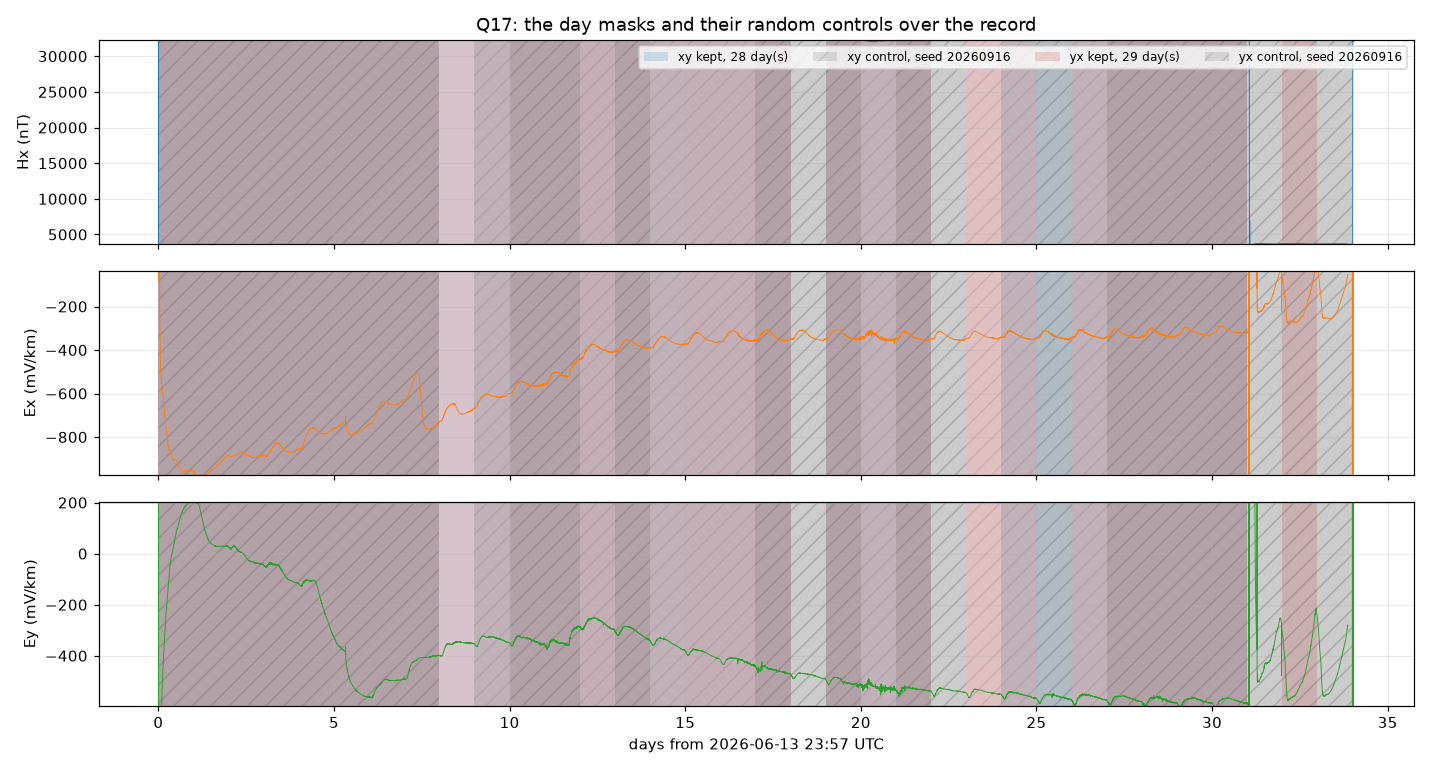

In [14]:
_t0m, _arrm, _metam = CACHE.load(SITE, WORK, 1)
spans = []
for comp in COMPONENTS:
    keep, ctrl, info = DAY_MASKS[comp]
    spans.append(("%s kept, %d day(s)" % (comp, info["days_kept"]), FF.SPAN_COLOUR[comp], None,
                  FF.mask_spans(keep, _t0m)))
    spans.append(("%s control, seed %d" % (comp, SEED), "0.4", "//", FF.mask_spans(ctrl, _t0m)))
fig = FF.record_spans(_t0m, _arrm, OUT / "10_day_masks.png", site=SITE, spans=spans,
                      title="%s: the day masks and their random controls over the record" % SITE)
WRITTEN.append(OUT / "10_day_masks.png")
display(Image(filename=str(OUT / "10_day_masks.png")))
del _arrm


In [15]:
THIN = {}
for comp in COMPONENTS:
    keep, ctrl, info = DAY_MASKS[comp]
    if not info["enough"]:
        # a mask keeping fewer than three days starves the long bands, so no pass is run on it: the pair is
        # UNJUDGED rather than made and then read
        THIN[comp] = info["days_kept"]
        print("   %s: the mask keeps %d day(s) of the %d scored, below the %d-day floor; no product is made"
              % (comp, info["days_kept"], info["days_scored"], MK.DAY_MIN_KEPT))
        continue
    form("daymask_%s" % comp, keep_extra=keep, seed=SEED,
         keep_name="%d whole day(s) at or above %.2f on the %s multiple coherence"
                   % (info["days_kept"], DAY_THR, QM["observatory"]),
         controls=["daymask_%s_control" % comp],
         criterion="beats its random control on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
    form("daymask_%s_control" % comp, keep_extra=ctrl, seed=SEED,
         keep_name="%d day(s) drawn at random from the same pool, seed %d" % (info["days_control"], SEED))
if not THIN:
    print("   every component's mask clears the %d-day floor" % MK.DAY_MIN_KEPT)


   every component's mask clears the 3-day floor


In [16]:
rows, bad, unjudged = [], [], []
for comp in COMPONENTS:
    info = DAY_MASKS[comp][2]
    if info["days_kept"] != info["days_control"]:
        bad.append("%s: the control keeps %d day(s) and the selection %d"
                   % (comp, info["days_control"], info["days_kept"]))
    if comp in THIN:
        unjudged.append("%s: the mask keeps %d day(s) of the %d scored, below the %d-day floor, so no "
                        "product was made and the pair is not scored"
                        % (comp, THIN[comp], info["days_scored"], MK.DAY_MIN_KEPT))
        continue
    for name in ("daymask_%s" % comp, "daymask_%s_control" % comp):
        r = made_product(name)
        if r is None:
            bad.append("%s was not made (%s)" % (name, str(rows_by_form().get(name, {}).get("error"))[:90]))
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(b) for b in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), runs=r.get("n_runs"), bar=rd.get("bar"),
                         bar_xy=rd.get("bar_xy"), bar_yx=rd.get("bar_yx"),
                         jumps_xy=rd.get("jumps_per_decade_xy"), jumps_yx=rd.get("jumps_per_decade_yx"),
                         rho_ratio_xy=rd.get("rho_ratio_xy"), rho_ratio_yx=rd.get("rho_ratio_yx")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no product to read")
beaten = []
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "daymask_%s" % comp), None)
    b = next((r for r in rows if r["form"] == "daymask_%s_control" % comp), None)
    if a and b:
        beaten.append((comp, DL.beats(a["bar"], b["bar"], BAR_MARGIN), a["bar"], b["bar"]))
print()
for comp, ok, x, y in beaten:
    print("   %s: bar %.4f against the control's %.4f -- %s"
          % (comp, x, y, "promoted" if ok else "NOT promoted: efficiency, not a different answer"))
promoted = [c for c, ok, _x, _y in beaten if ok]
inconsistent = [c for c, ok, x, y in beaten if ok and not DL.beats(x, y, BAR_MARGIN)]
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif inconsistent:
    print("VERDICT: FAIL -- %s promoted without beating its control on the %g-%g s bar by %.0f %%"
          % (", ".join(inconsistent), BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
elif unjudged:
    print("VERDICT: UNJUDGED -- %s%s" % ("; ".join(unjudged),
          ("; the pair(s) that were scored read " + "; ".join("%s %.4f against %.4f" % (c, x, y)
                                                              for c, ok, x, y in beaten)) if beaten else ""))
elif not beaten:
    print("VERDICT: UNJUDGED -- no mask and control pair was scored")
else:
    print("VERDICT: PASS -- every mask carries a control of the same day count drawn from the same pool "
          "under seed %d, every one of the %d pair(s) was scored on the %g-%g s bar (%s), and the %d "
          "promoted mask(s) (%s) each beat their control by at least %.0f %%"
          % (SEED, len(beaten), BAR_BAND[0], BAR_BAND[1],
             "; ".join("%s %.4f against %.4f" % (c, x, y) for c, ok, x, y in beaten),
             len(promoted), ", ".join(promoted) or "none", 100 * BAR_MARGIN))


              form   days  runs    bar  bar_xy  bar_yx  jumps_xy  jumps_yx  rho_ratio_xy  rho_ratio_yx
        daymask_xy 26.005    74 0.0375  0.2442  0.0375     0.000     0.000        0.9798        0.9930
daymask_xy_control 24.609    78 0.0765  0.4242  0.0765     0.000     0.000        1.0198        0.9962
        daymask_yx 26.649    79 0.0402  0.2563  0.0402     0.000     0.000        1.0063        0.9954
daymask_yx_control 25.402    85 0.0501  0.2913  0.0501     0.537     0.537        0.9905        0.9998

   xy: bar 0.0375 against the control's 0.0765 -- promoted
   yx: bar 0.0402 against the control's 0.0501 -- NOT promoted: efficiency, not a different answer
VERDICT: PASS -- every mask carries a control of the same day count drawn from the same pool under seed 20260916, every one of the 2 pair(s) was scored on the 10-1000 s bar (xy 0.0375 against 0.0765; yx 0.0402 against 0.0501), and the 1 promoted mask(s) (xy) each beat their control by at least 20 %


The whole-record product, each mask's product and each control's product on one set of panels.
What to look for is whether the three curves lie on each other: where they do, the mask changed nothing but
the error bars, which is the reading the verdict above prints as efficiency rather than a different
answer.

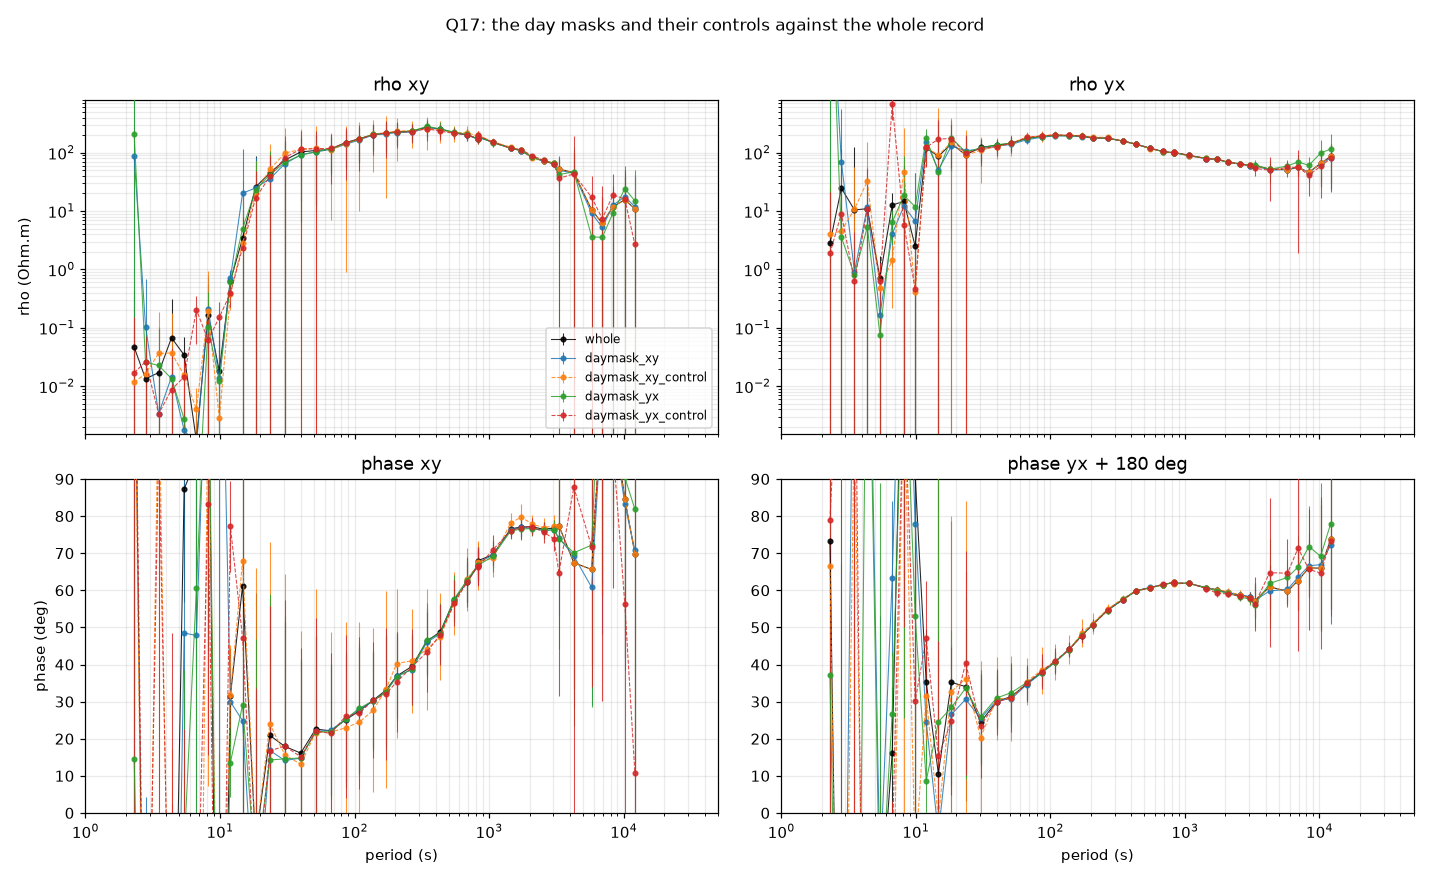

In [17]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
for k, comp in enumerate(COMPONENTS):
    for name, ls in (("daymask_%s" % comp, "-"), ("daymask_%s_control" % comp, "--")):
        r = made_product(name)
        if r:
            curves.append((name, read(r["product"]), "C%d" % (2 * k + (0 if ls == "-" else 1)), ls))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "11_daymask_products.png",
                         title="%s: the day masks and their controls against the whole record" % SITE,
                         period_range=(1, 50000))
    WRITTEN.append(OUT / "11_daymask_products.png")
    display(Image(filename=str(OUT / "11_daymask_products.png")))
else:
    print("no mask product was made, so there is nothing to draw against the whole record")


## 4. Windows

A line that dies mid-record is not a reason to throw the record away. The rule is the whole record for the
healthy row and for the tipper, the window for the other row, and BOTH windows in the provenance. The window
proposed here is the longest run of sound days of that line in the elines table; where no run of sound days
reaches the floor in survey.yaml the weak days are admitted and the row says so, so the window is a proposal
and not a finding. A window already in decisions.csv is used instead.

The windowed pass slices everything to the window, H included: the point of a window is that this component's
estimate sees only the days its electrode was alive, and an estimator handed a longer H than E would be
given NaN over the rest. The merge then replaces exactly that component's two impedance rows in a copy of the
whole-record product; the station block, the position, the tipper and every other row carry across untouched.

The control is a random block of the SAME LENGTH placed elsewhere in the record under the seed printed below.
A window that buys nothing beyond its length is one a block of the same length placed anywhere would buy.

**This check fails if the merge changes any row other than the windowed component's two, if a window lacks
its equal-length random block, or if a PROMOTED window does not beat that block on the 10-1000 s bar by at
least 20 per cent.** As in section 3, promotion is the reading and not the criterion (Ben, 2026-09-17): a
window that does not beat its block is printed as buying efficiency rather than a different answer and is not
carried forward, which is a finding about the site and not a defect of the workbook.

In [18]:
WINDOWS, WIN_ROWS = {}, []
cell = str(sv.decision(SITE).get("windows", "")).strip()
from_decisions = {}
if cell and cell.lower() not in ("decide", "nan", "none", ""):
    try:
        from_decisions = json.loads(cell)
    except Exception as exc:
        print("decisions.csv windows does not parse as JSON (%s); the proposal below is used" % exc)
for comp in COMPONENTS:
    d = from_decisions.get(comp) or {}
    if d.get("t_start"):
        w = dict(component=comp, t_start=int(pd.Timestamp(d["t_start"], tz="UTC").timestamp()),
                 t_end=int(pd.Timestamp(d["t_end"], tz="UTC").timestamp()), days=d.get("days"),
                 n_days=d.get("days"), reason="decisions.csv: %s" % d.get("reason", ""), states="")
    else:
        w = MK.window_from_days(ELINES, comp, min_days=FM.min_window_days(sv))
    seed = SEED + (0 if comp == "xy" else 1)
    if w["t_start"]:
        a, b = MK.random_block(t0_rec, n_rec, int(w["t_end"] - w["t_start"]), seed,
                               exclude=(w["t_start"] - t0_rec, w["t_end"] - t0_rec))
        w["control"] = (t0_rec + a, t0_rec + b)
    else:
        w["control"] = None
    w["seed"] = seed
    WINDOWS[comp] = w
    WIN_ROWS.append(dict(component=comp, line=LINE[comp], t_start=w["t_start"], t_end=w["t_end"],
                         days=w["days"], n_days=w["n_days"], seed=seed,
                         control_start=(w["control"][0] if w["control"] else None),
                         reason=w["reason"][:120]))
print(pd.DataFrame(WIN_ROWS).to_string(index=False))
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if w["t_start"]:
        print("   %s window %s .. %s (%.2f d); control block %s .. %s, the same length, seed %d"
              % (comp, pd.Timestamp(w["t_start"], unit="s"), pd.Timestamp(w["t_end"], unit="s"), w["days"],
                 pd.Timestamp(w["control"][0], unit="s"), pd.Timestamp(w["control"][1], unit="s"), w["seed"]))


component line    t_start      t_end  days  n_days     seed  control_start                                                                                                                   reason
       xy   Ex 1783468800 1784073600   7.0       7 20260916     1782366220 the longest run of sound+weak days of Ex: 7 day(s), 2026-07-08 to 2026-07-15; no run of sound days reaches the 0.50 d fl
       yx   Ey 1783468800 1783987200   6.0       6 20260917     1782161842                                                  the longest run of sound days of Ey: 6 day(s), 2026-07-08 to 2026-07-14
   xy window 2026-07-08 00:00:00 .. 2026-07-15 00:00:00 (7.00 d); control block 2026-06-25 05:43:40 .. 2026-07-02 05:43:40, the same length, seed 20260916
   yx window 2026-07-08 00:00:00 .. 2026-07-14 00:00:00 (6.00 d); control block 2026-06-22 20:57:22 .. 2026-06-28 20:57:22, the same length, seed 20260917


In [19]:
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        print("   %s: no window proposed (%s)" % (comp, w["reason"]))
        continue
    form("window_%s" % comp, window=(w["t_start"], w["t_end"]), seed=w["seed"],
         keep_name="the %s window, %.2f d" % (comp, w["days"]),
         controls=["window_%s_control" % comp],
         criterion="beats an equal-length random block on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN),
         extra_lines=["window_reason=%s" % w["reason"]])
    form("window_%s_control" % comp, window=w["control"], seed=w["seed"],
         keep_name="a random block of the same length elsewhere in the record, seed %d" % w["seed"])


The record with each component's window as a solid span and its equal-length random block
hatched. What to look for is the window sitting where that line's days are alive and the block landing
somewhere the line is neither obviously better nor worse: the two cost the same, so the difference between
their products is what the window bought.

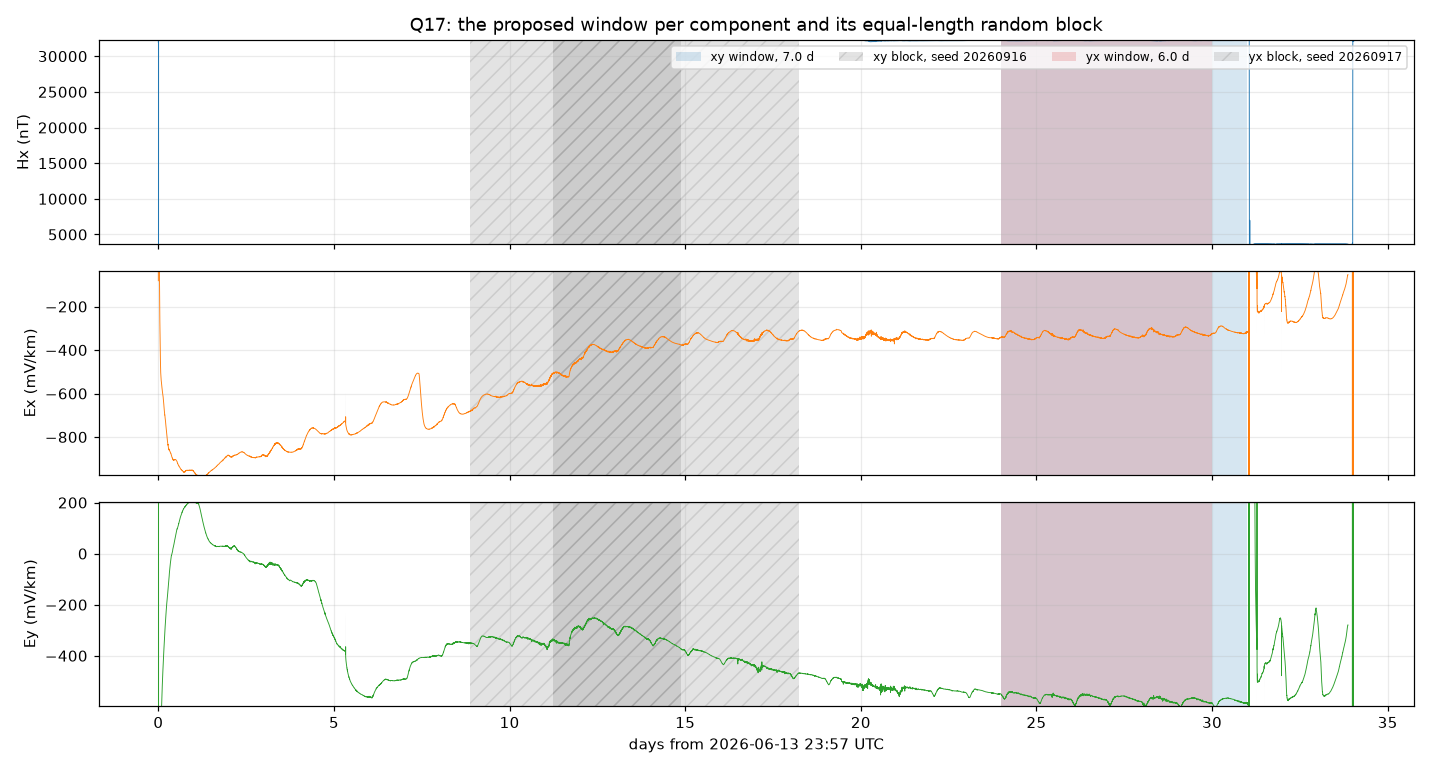

In [20]:
_t0w, _arrw, _metaw = CACHE.load(SITE, WORK, 1)
spans = []
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        continue
    spans.append(("%s window, %.1f d" % (comp, w["days"]), FF.SPAN_COLOUR[comp], None,
                  [(w["t_start"], w["t_end"])]))
    spans.append(("%s block, seed %d" % (comp, w["seed"]), "0.4", "//", [w["control"]]))
fig = FF.record_spans(_t0w, _arrw, OUT / "12_windows_record.png", site=SITE, spans=spans,
                      title="%s: the proposed window per component and its equal-length random block" % SITE)
WRITTEN.append(OUT / "12_windows_record.png")
display(Image(filename=str(OUT / "12_windows_record.png")))
del _arrw


In [21]:
MERGES = []
for comp in COMPONENTS:
    r = made_product("window_%s" % comp)
    if r is None or not BASE:
        continue
    out = OUT / FM.product_name(SITE, "merged_%s" % comp, BASELINE_KIND, 1, PARAMS)
    got = FM.merge_component(BASE, r["product"], comp, out_edi=out, verbose=False)
    MERGES.append(got)
    print("   %s: %s; rows changed %s (expected %s); every other row unchanged: %s"
          % (comp, got["how"], ", ".join(got["rows_changed"]) or "none", ", ".join(got["rows_expected"]),
             got["untouched_unchanged"]))
    FORM_ROWS.append(dict(site=SITE, form="merged_%s" % comp, kind=BASELINE_KIND, rate_hz=1.0,
                          params=PARAMS, product=str(out), controls="", seed=None, status="made",
                          criterion="the whole record for the healthy row and the tipper, the %s window for "
                                    "the other" % comp, error="", days=None, n_runs=None, seconds=None))
if not MERGES:
    print("   no windowed product was made, so nothing was merged")


   xy: grids identical to 0.0e+00 relative; rows changed xx, xy (expected xx, xy); every other row unchanged: True
   yx: grids identical to 0.0e+00 relative; rows changed yx, yy (expected yx, yy); every other row unchanged: True


In [22]:
rows, bad = [], []
for comp in COMPONENTS:
    w = WINDOWS[comp]
    if not w["t_start"]:
        bad.append("%s: no window was proposed (%s)" % (comp, w["reason"][:80]))
        continue
    for name in ("window_%s" % comp, "window_%s_control" % comp):
        r = made_product(name)
        if r is None:
            bad.append("%s was not made (%s)" % (name, str(rows_by_form().get(name, {}).get("error"))[:90]))
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(b) for b in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), bar=rd.get("bar"), bar_xy=rd.get("bar_xy"),
                         bar_yx=rd.get("bar_yx"), rho_ratio_xy=rd.get("rho_ratio_xy"),
                         rho_ratio_yx=rd.get("rho_ratio_yx"), phase_xy=rd.get("phase_diff_xy"),
                         per_decade=rd.get("per_decade", "")[:60]))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no windowed product to read")
beaten = []
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "window_%s" % comp), None)
    b = next((r for r in rows if r["form"] == "window_%s_control" % comp), None)
    if a and b:
        beaten.append((comp, DL.beats(a["bar"], b["bar"], BAR_MARGIN), a["bar"], b["bar"]))
print()
for m in MERGES:
    print("   merge %s: rows changed %s; every other row unchanged %s"
          % (m["component"], ",".join(m["rows_changed"]) or "none", m["untouched_unchanged"]))
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif not MERGES:
    print("VERDICT: UNJUDGED -- no window was merged, so the merge was not scored")
elif not all(m["ok"] for m in MERGES):
    print("VERDICT: FAIL -- a merge changed a row other than its component's two: %s"
          % "; ".join("%s changed %s" % (m["component"], ",".join(m["rows_changed"]))
                      for m in MERGES if not m["ok"]))
elif not beaten:
    print("VERDICT: UNJUDGED -- no window and control pair was scored")
else:
    promoted = [c for c, ok, _x, _y in beaten if ok]
    inconsistent = [c for c, ok, x, y in beaten if ok and not DL.beats(x, y, BAR_MARGIN)]
    if inconsistent:
        print("VERDICT: FAIL -- %s promoted without beating its random block on the %g-%g s bar by %.0f %%"
              % (", ".join(inconsistent), BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN))
    else:
        print("VERDICT: PASS -- every merge changed exactly its component's two rows (%s) and left the rest "
              "untouched, every window carries an equal-length random block, and the %d promoted window(s) "
              "(%s) beat their block on the %g-%g s bar by at least %.0f %%: %s"
              % ("; ".join("%s -> %s" % (m["component"], ",".join(m["rows_changed"])) for m in MERGES),
                 len(promoted), ", ".join(promoted) or "none", BAR_BAND[0], BAR_BAND[1],
                 100 * BAR_MARGIN,
                 "; ".join("%s %.4f against %.4f%s" % (c, x, y, "" if ok else ", not promoted")
                           for c, ok, x, y in beaten)))


             form  days    bar  bar_xy  bar_yx  rho_ratio_xy  rho_ratio_yx  phase_xy                                                   per_decade
        window_xy 6.722 0.0410  0.1933  0.0410        0.9302        0.9769   -1.4594 5-10 s xy 5.12 +130.5 deg; 5-10 s yx 4.46 -114.7 deg; 10-100
window_xy_control 6.669 0.0533  0.3000  0.0533        1.0023        0.9912   -0.2420 5-10 s xy 0.93 +27.5 deg; 5-10 s yx 0.61 +50.7 deg; 10-100 s
        window_yx 5.736 0.0459  0.2287  0.0459        0.9416        0.9821   -2.1117 5-10 s xy 2.01 +150.2 deg; 5-10 s yx 12.18 -109.2 deg; 10-10
window_yx_control 5.603 0.0743  0.4738  0.0743        0.9387        0.9917    1.4372 5-10 s xy 3.29 +59.0 deg; 5-10 s yx 1.80 -14.7 deg; 10-100 s

   merge xy: rows changed xx,xy; every other row unchanged True
   merge yx: rows changed yx,yy; every other row unchanged True
VERDICT: PASS -- every merge changed exactly its component's two rows (xy -> xx,xy; yx -> yx,yy) and left the rest untouched, every window ca

The windowed product, its random block and the merged file against the whole record. What to
look for is the merged curve following the whole record on the row the window did NOT touch and the windowed
curve on the row it did: that is the merge rule drawn, and a departure on the untouched row is the failure
the check above scores.

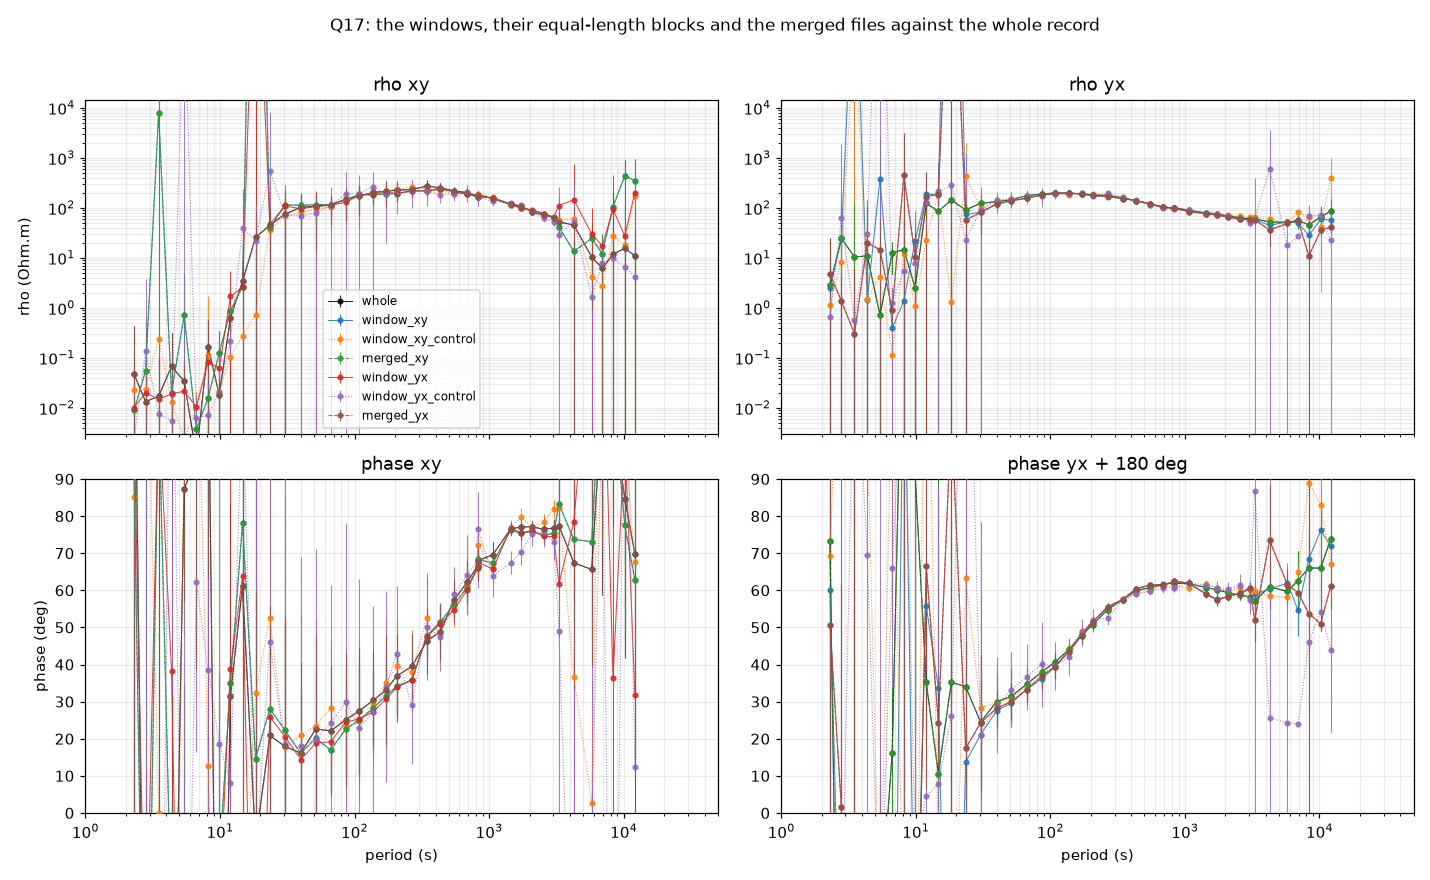

In [23]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
styles = {"window": ("-", 0), "control": (":", 1), "merged": ("--", 2)}
for k, comp in enumerate(COMPONENTS):
    for name, key in (("window_%s" % comp, "window"), ("window_%s_control" % comp, "control"),
                      ("merged_%s" % comp, "merged")):
        r = made_product(name)
        if r:
            ls, off = styles[key]
            curves.append((name, read(r["product"]), "C%d" % (3 * k + off), ls))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "13_window_products.png",
                         title="%s: the windows, their equal-length blocks and the merged files against the "
                               "whole record" % SITE, period_range=(1, 50000))
    WRITTEN.append(OUT / "13_window_products.png")
    display(Image(filename=str(OUT / "13_window_products.png")))
else:
    print("no windowed product was made, so there is nothing to draw against the whole record")


## 5. Best hours

The hours of the record are scored by the coherence of the component's pair over HOURS_BAND on
non-overlapping one-hour windows, and the best HOURS_FRACTION of the candidate windows is kept. The candidate
pool is the hours whose day the elines table calls sound; where that leaves fewer than 24 candidates the weak
days are admitted and the selection says so.

Three things are scored beside it and the section is not read without them. The RANDOM control keeps the same
number of windows drawn without replacement from the same pool under SEED and is expected NOT to separate
kept from dropped -- if it does, the statistic is not measuring what the selection claims. The CONTIGUOUS
controls tile windows of CONTIG_HOURS hours from the first whole hour, score each by the mean of its hours
and take the top ones until the kept duration matches the selection's to within one window; one Aurora window
at the deepest decimation level is 65,536 s, so a scattered selection cannot reach the long periods at all
and only a contiguous comparison at the same cost decides a long-period claim. The products of all three are
read against the baseline.

**This check fails if the ranked selection does not separate kept from dropped on the selecting statistic, if
the random control separates by more than a fifth of the ranked selection's separation, or if a contiguous
control's duration misses the selection's by more than one window.** A random split of a scored pool
separates by a small amount half the time, so the random control's limb is read as a share of the ranked
selection's own separation and not as a sign test, which would be a coin toss and not a criterion.

In [24]:
HOURS = {}
for comp in COMPONENTS:
    t = time.time()
    HOURS[comp] = MK.best_hours(sv, SITE, comp, ELINES, band=tuple(HOURS_BAND), fraction=HOURS_FRACTION,
                                seed=SEED, contig_hours=tuple(CONTIG_HOURS))
    b = HOURS[comp]
    print("%s in %.0f s: %d candidate window(s) (%s), %d kept above %.3f, %.2f d; random %.2f d"
          % (comp, time.time() - t, b["n_candidates"], b["admitted"], b["n_selected"], b["threshold"],
             b["days_kept"], b["days_random"]))
rows = []
for comp in COMPONENTS:
    b = HOURS[comp]
    rows.append(dict(component=comp, set="ranked", n_windows=b["n_selected"], days=b["days_kept"],
                     median_kept=b["median_kept"], median_dropped=b["median_dropped"],
                     separates=b["separates"], matches=True))
    rows.append(dict(component=comp, set="random", n_windows=b["n_selected"], days=b["days_random"],
                     median_kept=b["random_median_kept"], median_dropped=b["random_median_dropped"],
                     separates=b["random_separates"], matches=True,
                     gap_share_of_ranked=b["random_gap_fraction"]))
    for h, c in sorted(b["contiguous"].items()):
        rows.append(dict(component=comp, set="contiguous %d h" % h, n_windows=c["n_windows"],
                         days=round(c["hours"] / 24.0, 3), median_kept=c["kept"],
                         median_dropped=c["dropped"], separates=c["discriminates"], matches=c["matches"]))
HOURS_TABLE = pd.DataFrame(rows)
print(HOURS_TABLE.round(4).to_string(index=False))


xy in 2 s: 624 candidate window(s) (weak days admitted (fewer than 24 candidates on sound)), 156 kept above 0.034, 6.50 d; random 6.50 d


yx in 2 s: 288 candidate window(s) (days in state sound), 72 kept above 0.047, 3.00 d; random 3.00 d
component             set  n_windows  days  median_kept  median_dropped  separates  matches  gap_share_of_ranked
       xy          ranked        156   6.5       0.0400          0.0278       True     True                  NaN
       xy          random        156   6.5       0.0295          0.0293      False     True               0.0144
       xy  contiguous 2 h         78   6.5       0.0750          0.0283       True     True                  NaN
       xy  contiguous 4 h         39   6.5       0.0740          0.0286       True     True                  NaN
       xy  contiguous 6 h         26   6.5       0.0725          0.0291       True     True                  NaN
       xy contiguous 24 h          6   6.0       0.0695          0.0311       True     True                  NaN
       yx          ranked         72   3.0       0.0575          0.0359       True     True                 

In [25]:
CONTIG_PICK, THIN_HOURS = {}, {}
for comp in COMPONENTS:
    b = HOURS[comp]
    if not b["n_selected"]:
        THIN_HOURS[comp] = b["n_candidates"]
        print("   %s: %d candidate window(s) and %d selected; no product is made"
              % (comp, b["n_candidates"], b["n_selected"]))
        continue
    ok = [(h, c) for h, c in sorted(b["contiguous"].items()) if c["matches"] and c["n_windows"]]
    if not ok:
        print("   %s: no contiguous set matches the selection's duration; none is run" % comp)
        continue
    h, c = min(ok, key=lambda hc: abs(hc[1]["hours"] - b["n_selected"]))
    CONTIG_PICK[comp] = h
    form("hours_%s" % comp, keep_extra=b["keep"], seed=SEED,
         keep_name="the best %.0f %% of %d candidate hour window(s) by %g-%g s coherence"
                   % (100 * HOURS_FRACTION, b["n_candidates"], HOURS_BAND[0], HOURS_BAND[1]),
         controls=["hours_%s_random" % comp, "hours_%s_contig%dh" % (comp, h)],
         criterion="beats its random and contiguous controls on the %g-%g s bar by %.0f %%"
                   % (BAR_BAND[0], BAR_BAND[1], 100 * BAR_MARGIN),
         extra_lines=["selection_statistic=%g-%g s coherence of %s with %s, one value an hour; kept median "
                      "%.3f against the dropped %.3f"
                      % (HOURS_BAND[0], HOURS_BAND[1], LINE[comp], COMP_H[comp], b["median_kept"],
                         b["median_dropped"])])
    form("hours_%s_random" % comp, keep_extra=b["random_keep"], seed=SEED,
         keep_name="%d window(s) drawn at random from the same pool, seed %d" % (b["n_selected"], SEED))
    form("hours_%s_contig%dh" % (comp, h), keep_extra=b["contiguous"][h]["keep"], seed=SEED,
         keep_name="the top %d contiguous %d h window(s), %d h against the selection's %d h"
                   % (b["contiguous"][h]["n_windows"], h, b["contiguous"][h]["hours"], b["n_selected"]))


The hour score through the record, with the three selections drawn as rows of spans above it:
the kept hours, the random hours of the same size, and the contiguous windows of the same duration. What to
look for is where the kept hours sit relative to the score -- they are its top by construction -- and how
differently the three rows cover the record, because their coverage is the only thing separating them.

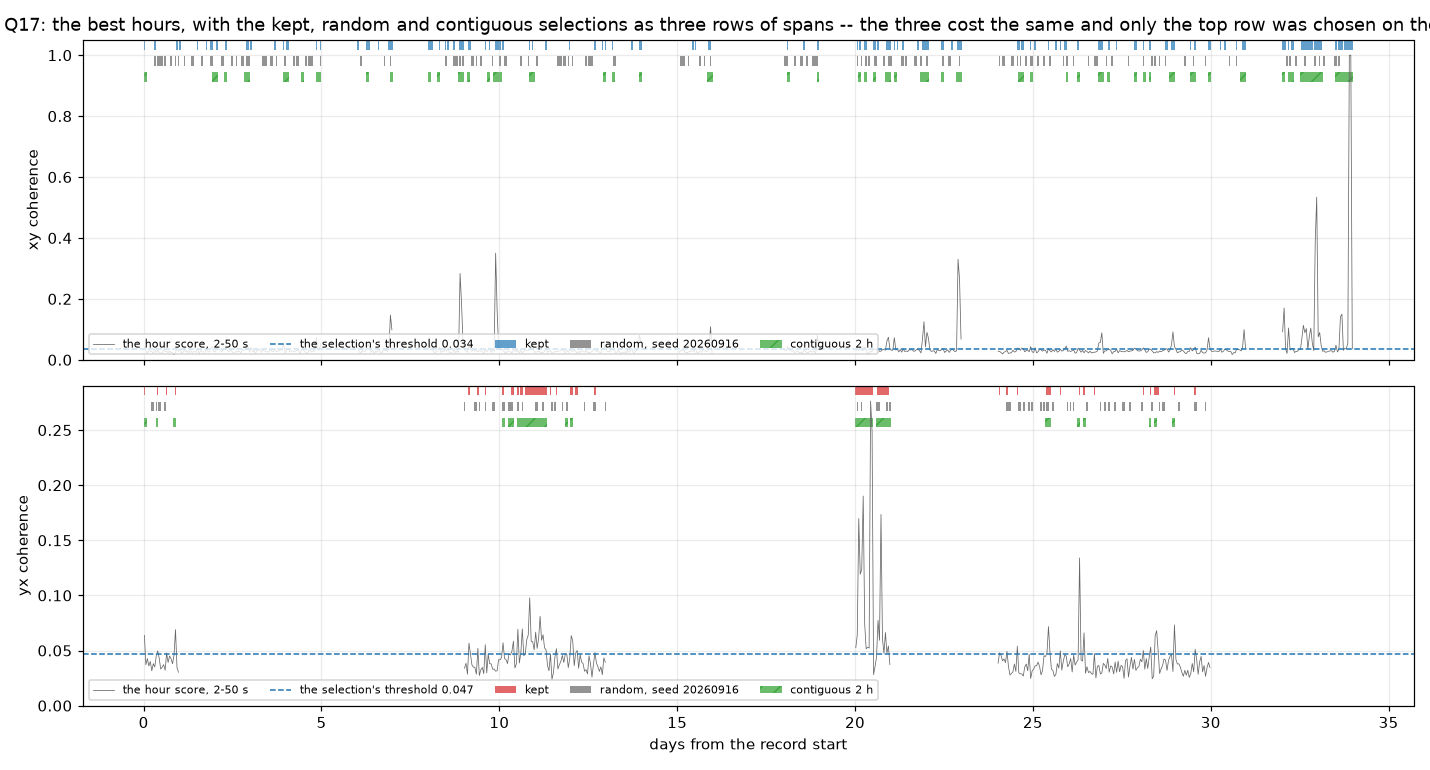

In [26]:
fig = FF.hour_scores(HOURS, SITE, OUT / "14_hour_scores.png", comps=COMPONENTS,
                     contig_pick=CONTIG_PICK)
WRITTEN.append(OUT / "14_hour_scores.png")
display(Image(filename=str(OUT / "14_hour_scores.png")))


In [27]:
rows, bad = [], []
for comp in COMPONENTS:
    b = HOURS[comp]
    if comp in THIN_HOURS:
        bad.append("%s: UNJUDGED -- %d candidate window(s), so nothing was selected and nothing was scored"
                   % (comp, THIN_HOURS[comp]))
        continue
    if not b["separates"]:
        bad.append("%s: the ranked selection's kept median %.3f is not above the dropped %.3f"
                   % (comp, b["median_kept"], b["median_dropped"]))
    if b["random_separates"]:
        bad.append("%s: the RANDOM control separates by %.4f, %.0f %% of the ranked selection's %.4f, above "
                   "the %.0f %% the criterion allows, so the statistic is not measuring the selection"
                   % (comp, b["random_gap"], 100 * b["random_gap_fraction"], b["gap"],
                      100 * b["random_gap_max"]))
    for h, c in sorted(b["contiguous"].items()):
        if not c["matches"]:
            bad.append("%s: the contiguous %d h set keeps %d h against the selection's %d h, more than one "
                       "window out" % (comp, h, c["hours"], b["n_selected"]))
    names = ["hours_%s" % comp, "hours_%s_random" % comp]
    if comp in CONTIG_PICK:
        names.append("hours_%s_contig%dh" % (comp, CONTIG_PICK[comp]))
    for name in names:
        r = made_product(name)
        if r is None:
            continue
        rd = DL.reading(read(r["product"]), read(BASE) if BASE else None,
                        bands=[tuple(x) for x in DECADES], bar_band=tuple(BAR_BAND),
                        agree_band=tuple(AGREE_BAND))
        rows.append(dict(form=name, days=r.get("days"), bar=rd.get("bar"), bar_xy=rd.get("bar_xy"),
                         bar_yx=rd.get("bar_yx"), rho_ratio_xy=rd.get("rho_ratio_xy"),
                         rho_ratio_yx=rd.get("rho_ratio_yx"), jumps_xy=rd.get("jumps_per_decade_xy")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no selection product to read")
print()
for comp in COMPONENTS:
    a = next((r for r in rows if r["form"] == "hours_%s" % comp), None)
    ctl = [r for r in rows if r["form"].startswith("hours_%s_" % comp)]
    if a and ctl:
        print("   %s: bar %.4f against %s -- %s"
              % (comp, a["bar"], ", ".join("%s %.4f" % (c["form"].split("_")[-1], c["bar"]) for c in ctl),
                 "promoted" if all(DL.beats(a["bar"], c["bar"], BAR_MARGIN) for c in ctl)
                 else "NOT promoted: efficiency, not a different answer"))
if bad:
    print("VERDICT: FAIL -- %s" % "; ".join(bad))
elif not len(HOURS_TABLE):
    print("VERDICT: UNJUDGED -- no component was scored")
else:
    print("VERDICT: PASS -- on every component the ranked selection separates kept from dropped (%s), the "
          "random control separates by at most a fifth of that (%s), and every contiguous set's duration "
          "matches the selection's to within one window"
          % ("; ".join("%s %.3f over %.3f" % (c, HOURS[c]["median_kept"], HOURS[c]["median_dropped"])
                       for c in COMPONENTS),
             "; ".join("%s %.4f against %.4f" % (c, HOURS[c]["random_gap"], HOURS[c]["gap"])
                       for c in COMPONENTS)))


             form  days    bar  bar_xy  bar_yx  rho_ratio_xy  rho_ratio_yx  jumps_xy
         hours_xy 5.173 0.1032  0.3998  0.1032        1.2714        1.0896     0.000
  hours_xy_random 5.573 0.1422  0.7506  0.1422        0.9318        1.0005     0.000
hours_xy_contig2h 5.040 0.0692  0.3227  0.0692        0.9524        1.0341     0.321
         hours_yx 2.450 0.0336  0.2271  0.0336        0.8466        0.9940     0.000
  hours_yx_random 2.625 0.0784  0.3571  0.0784        0.7975        0.9453     0.000
hours_yx_contig2h 2.403 0.0354  0.1816  0.0354        0.8911        0.9914     0.000

   xy: bar 0.1032 against random 0.1422, contig2h 0.0692 -- NOT promoted: efficiency, not a different answer
   yx: bar 0.0336 against random 0.0784, contig2h 0.0354 -- NOT promoted: efficiency, not a different answer
VERDICT: PASS -- on every component the ranked selection separates kept from dropped (xy 0.040 over 0.028; yx 0.057 over 0.036), the random control separates by at most a fifth of that (

The four products of each component on one set of panels: the whole record, the selection, its
random control and its contiguous control. What to look for is the long end, where a scattered selection
cannot reach and the contiguous one can: the deepest Aurora window is 65,536 s, so any claim above a few
thousand seconds belongs to the contiguous curve and not to the scattered one.

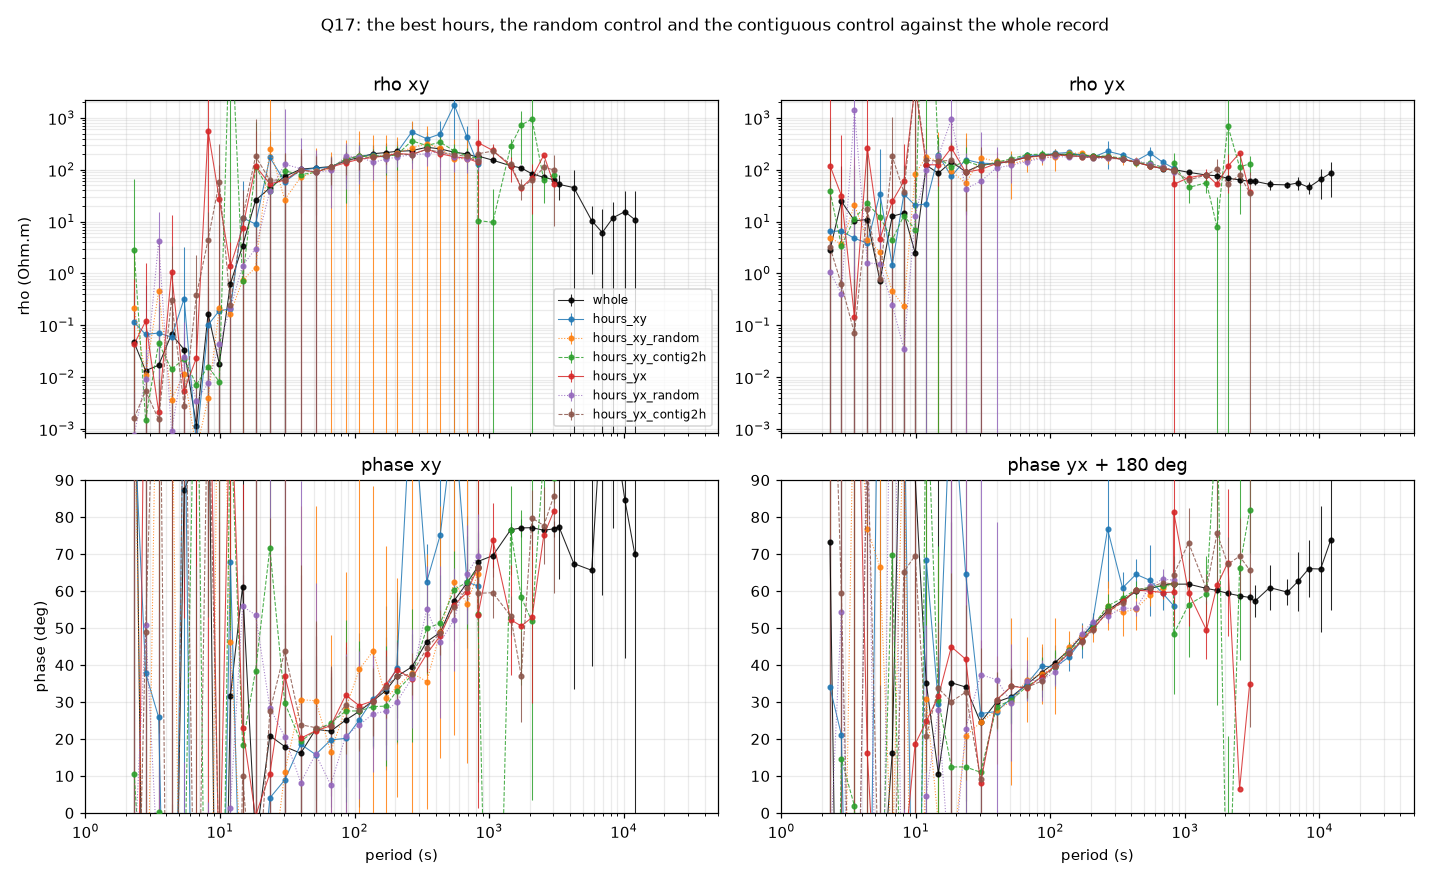

In [28]:
curves = [("whole", read(BASE), "k", "-")] if BASE else []
for k, comp in enumerate(COMPONENTS):
    names = ["hours_%s" % comp, "hours_%s_random" % comp]
    if comp in CONTIG_PICK:
        names.append("hours_%s_contig%dh" % (comp, CONTIG_PICK[comp]))
    for j, name in enumerate(names):
        r = made_product(name)
        if r:
            curves.append((name, read(r["product"]), "C%d" % (3 * k + j), ("-", ":", "--")[j]))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "15_hours_products.png",
                         title="%s: the best hours, the random control and the contiguous control against "
                               "the whole record" % SITE, period_range=(1, 50000))
    WRITTEN.append(OUT / "15_hours_products.png")
    display(Image(filename=str(OUT / "15_hours_products.png")))
else:
    print("no selection product was made, so there is nothing to draw against the whole record")


## 6. The shared centre and the north-minus-east diagonal

The EDL L layout is three electrodes: a shared centre and two arms, so a noisy centre puts one voltage on
both lines. With the lines physically signed the model reads Ex = Ex_true + c and Ey = Ey_true + s c, with
s = +1 for arms north and east (or south and west) and -1 where one arm is reversed. The E signs in
decisions.csv predict s; an undecided sign is never filled by convention and leaves the site UNJUDGED on that
prediction.

The residual test removes the part of each line that (Hx, Hy) explains, per frequency bin, from the
cross-spectra at 20-200 s on the CENTRE_DAYS days of highest Ex-Ey coherence, and reads what is left: the
model holds where the residual coherence is at least 0.9 and the complex gain is between 0.85 and 1.18, and
the sign of the real part of the gain is the observed s. The clean diagonal is the one whose multiple
coherence with (Hx, Hy) is the higher.

The CONTROL is BUILT, not found (Ben, 2026-09-17). The site's own Ex is paired with the nearest sound site's
Ey, both read against the site's own (Hx, Hy) over the same days, and the residual test is run on that pair:
two electrodes tens of kilometres apart have no common voltage, so the model must NOT hold there. That is a
change of criterion and not a relaxation of one. The criterion used until then was a site of the same group
whose own Ex-Ey coherence stays under 0.35 on every day, and such a site need not exist: a one-dimensional
earth correlates the two lines through the source field alone, and no site of AusLAMP Queensland Phase 1
clears the ceiling, the lowest daily maximum in the survey being 0.354. A control that may not exist leaves
the section UNJUDGED wherever the survey is layered; the built pair exists at every site with a neighbour.
The found control site is kept as a READING beside it, with the ceiling it did or did not clear.

Where the model holds, the remedy is the north-minus-east diagonal: V_N - V_E = L (Ex - Ey) is the voltage
across the diagonal of length L sqrt 2, so Ex' = (Ex - Ey)/sqrt 2 is the field along the north-west diagonal
and free of the centre, and Ey' = (Ex + Ey)/sqrt 2 carries the centre doubled. The pair is E in the frame
turned by -45 deg, so a pass on the variant cache gives R Z and turning the H columns as well completes
Z' = (R Z) R^T. The x' row is the clean one; the y' row is kept for the record. The turn is checked on the
elements to 1e-6 relative, on the determinant to 1e-5 of the squared Frobenius norm -- the relative form is
meaningless at a near-singular period -- and on the Frobenius norm to 1e-6. The trace is NOT an invariant of
a column-only turn and its ratio is printed as the counter-example.

**This check fails if the BUILT control holds the model, if it could not be built, if the variant cache does
not reproduce (Ex - Ey)/sqrt 2 of the signed source at every finite sample, if the turn-back changes an
invariant beyond its tolerance, or if a sign prediction disagrees with the observed sign where both
exist.**

In [29]:
BUILT = CE.built_control(sv, SITE, days=CENTRE_DAYS, elines=ELINES, members=SITES)
print("the built control: %s -- %s" % (BUILT.get("site"), BUILT.get("reason")))
CTRL = CE.control_site(sv, SITE, SITES)
print("the found control site (a reading): %s -- %s" % (CTRL.get("site"), CTRL.get("reason")))
if "table" in CTRL:
    print(CTRL["table"].head(6).round(3).to_string(index=False))
print("it qualifies under the %.2f ceiling on every scored day: %s"
      % (CE.CONTROL_EX_EY_MAX, CTRL.get("qualifies")))
print()
CENTRE = {SITE: CE.residual_test(sv, SITE, CENTRE_DAYS, ELINES)}
if BUILT.get("judged"):
    CENTRE[BUILT["site"]] = BUILT
if CTRL.get("site"):
    CENTRE[CTRL["site"]] = CE.residual_test(sv, CTRL["site"], CENTRE_DAYS,
                                            CE.read_elines(sv, CTRL["site"]))
cols = ["site", "days", "src_coh", "resid_coh", "resid_gain", "s_pred", "s_obs", "sign_undecided",
        "mcoh_diff", "mcoh_sum", "model_holds", "control", "clean_pred", "clean_obs", "clean_by_H",
        "sign_agrees", "remedy_applicable"]
CENTRE_TABLE = pd.DataFrame([{k: v.get(k) for k in cols} for v in CENTRE.values() if v.get("judged")])
print(CENTRE_TABLE.round(3).to_string(index=False) if len(CENTRE_TABLE) else "no site produced a usable day")


the built control: Q17 Ex + Q21 Ey -- the site's own Ex against Q21's Ey, both on the site's own H over the same days: two electrodes that cannot share a centre
the found control site (a reading): Q27 -- the lowest daily maximum Ex-Ey coherence of the group (0.105 over 31 scored days)
site  max_coh_Ex_Ey  median_coh_Ex_Ey  days
 Q27          0.105             0.021    31
 Q34          0.302             0.123    37
 Q55          0.561             0.288    31
 Q22          0.605             0.282    34
 Q28          0.611             0.216    37
 Q32          0.760             0.143    37
it qualifies under the 0.35 ceiling on every scored day: True



           site                             days  src_coh  resid_coh  resid_gain  s_pred  s_obs sign_undecided  mcoh_diff  mcoh_sum  model_holds control clean_pred clean_obs clean_by_H sign_agrees remedy_applicable
            Q17 2026-07-03 2026-07-07 2026-06-19    0.691      0.649       0.534    -1.0    1.0                     0.375     0.527        False   False        sum      diff        sum        None             False
Q17 Ex + Q21 Ey 2026-07-03 2026-07-07 2026-06-19    0.655      0.557       0.708     NaN    NaN            NaN      0.476     0.375        False    None        NaN       NaN        NaN        None              None
            Q27 2026-06-19 2026-06-29 2026-07-10    0.086      0.091       0.029     1.0    1.0                     0.041     0.040        False    True       diff      diff       diff        None             False


The residual test drawn: the residual coherence and the complex gain against frequency over the
band, for the site and for the built control, with the 0.9 coherence line and the 0.85-1.18 gain band. What
to look for is the site's coherence riding along the top of the band with a gain sitting inside the box while
the built control's coherence lies on the floor: the gap between the two lines is what says the test can tell
a shared centre from a pair that cannot have one.

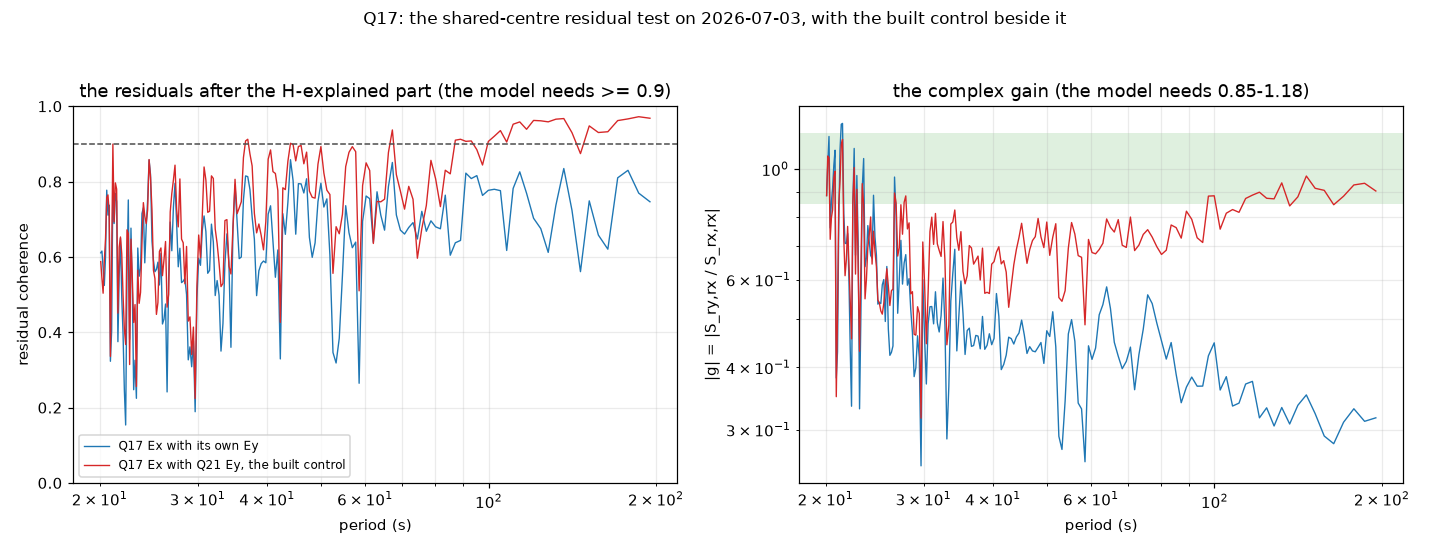

In [30]:
fig = FF.residual_panels(sv, SITE, CENTRE.get(SITE, {}), BUILT, OUT / "16_centre_residual.png",
                         days=CENTRE_DAYS, elines=ELINES, band_s=CE.BAND_S)
WRITTEN.append(OUT / "16_centre_residual.png")
display(Image(filename=str(OUT / "16_centre_residual.png")))


In [31]:
NE, DIAG = dict(written=False), None
me = CENTRE.get(SITE, {})
if me.get("model_holds"):
    NE = CE.ne_variant(sv, SITE, 1, force=REDO)
    print("the NE variant cache: %s (%s; Ex' equals (Ex - Ey)/sqrt2 of the signed source at every one of "
          "the %s finite samples: %s)"
          % (NE.get("path"), "written" if NE.get("written") else "already on disk and checked again",
             NE.get("n_finite"), NE.get("exact")))
    DIAG = form("diagonal", variant="ne", apply_e_signs=False, turn_ne=True,
                criterion="the turn-back keeps the element, determinant and Frobenius invariants of a "
                          "column-only turn",
                extra_lines=["diagonal=x' north-west = (Ex - Ey)/sqrt2, the clean row where the model "
                             "holds; y' north-east = (Ex + Ey)/sqrt2, kept for the record"])
    t = DIAG.get("turn") or {}
    if t:
        print("   the turn-back over %d period(s): elements %.2e (tolerance %.0e), determinant %.2e scaled "
              "(tolerance %.0e), Frobenius %.2e (tolerance %.0e); the trace ratio is %.3f, which is why the "
              "trace is not one of the criteria"
              % (t["n"], t["max_element_rel"], CE.ELEMENT_RTOL, t["max_det_scaled"], CE.DET_SCALED_TOL,
                 t["max_frobenius_rel"], CE.FROBENIUS_RTOL, t["trace_ratio"]))
    print("   the remedy %s at %s: the clean diagonal by the observed sign is the %s and by H coherence the "
          "%s" % ("applies" if me.get("remedy_applicable") else "does NOT apply", SITE,
                  me.get("clean_obs"), me.get("clean_by_H")))
else:
    print("the model does not hold at %s (residual coherence %.2f, gain %.2f): no variant cache is written"
          % (SITE, me.get("resid_coh", np.nan), me.get("resid_gain", np.nan)))


the model does not hold at Q17 (residual coherence 0.65, gain 0.53): no variant cache is written


One day of the two signed lines above and the two diagonals below. What to look for is the two
lines moving together -- that common motion is the centre's voltage -- and the difference beneath them,
which is what the north-west diagonal keeps after it has cancelled.

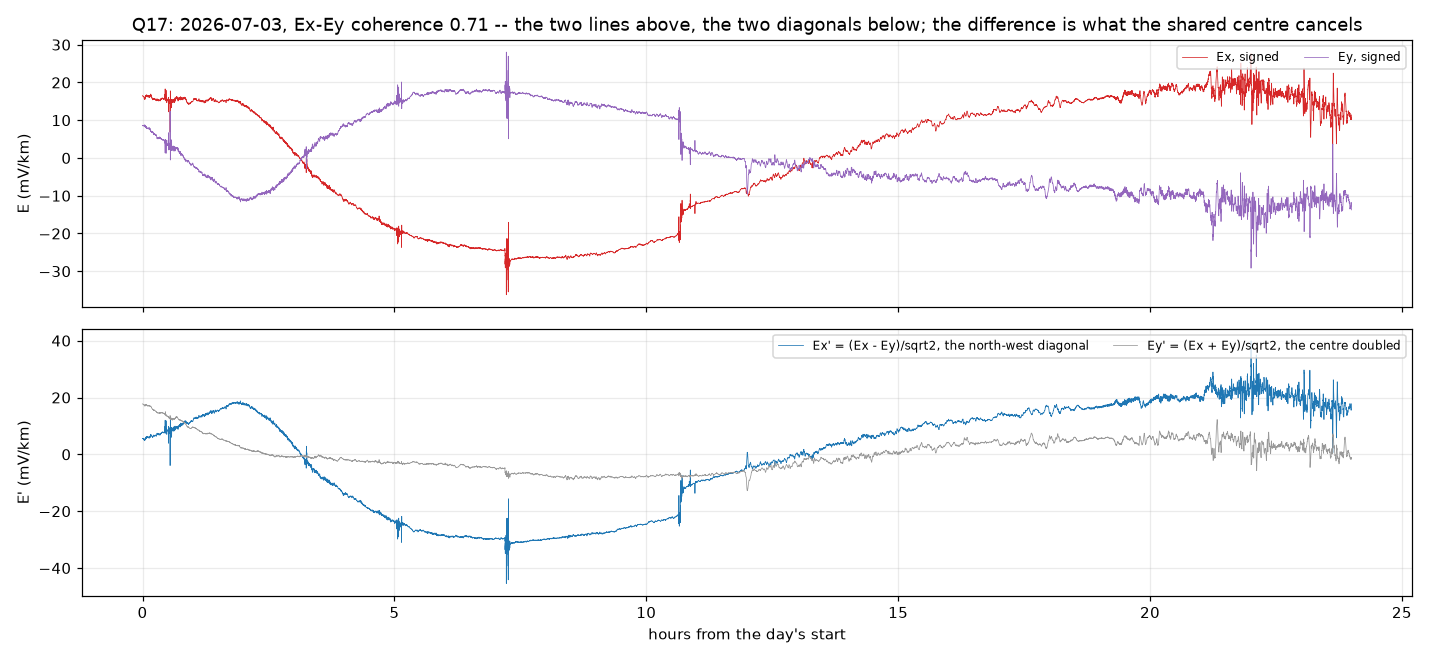

In [32]:
fig = FF.diagonal_day(sv, SITE, OUT / "17_diagonal_day.png", elines=ELINES)
WRITTEN.append(OUT / "17_diagonal_day.png")
display(Image(filename=str(OUT / "17_diagonal_day.png")))


The diagonal product against the baseline, where one was built. The x' row is the north-west
diagonal and not the xy component, so the two curves are not the same quantity and are not expected to lie on
each other: what to look for is whether the x' row is smoother and carries a smaller bar than the row the
shared centre sits in.

In [33]:
r = made_product("diagonal")
if r and BASE:
    fig = FF.form_panels([("whole", read(BASE), "k", "-"), ("diagonal", read(r["product"]), "C0", "-")],
                         SITE, OUT / "18_diagonal_product.png",
                         title="%s: the diagonal pass turned back to -45 deg, against the baseline -- the x' "
                               "row is the north-west diagonal, not xy" % SITE, period_range=(1, 50000))
    WRITTEN.append(OUT / "18_diagonal_product.png")
    display(Image(filename=str(OUT / "18_diagonal_product.png")))
else:
    print("no diagonal product was built, so there is nothing to draw against the baseline")


no diagonal product was built, so there is nothing to draw against the baseline


In [34]:
fail = []
me = CENTRE.get(SITE, {})
ctrl_row = CENTRE.get(CTRL.get("site"), {})
if not BUILT.get("judged"):
    fail.append("the control could not be built (%s), so the test was not shown able to fail"
                % BUILT.get("reason"))
elif BUILT.get("model_holds"):
    fail.append("the built control %s holds the model (residual coherence %.2f, gain %.2f): the test finds a "
                "shared centre between two electrodes that cannot have one"
                % (BUILT["site"], BUILT["resid_coh"], BUILT["resid_gain"]))
if me.get("sign_undecided"):
    fail.append("UNJUDGED on the sign prediction at %s: %s undecided in decisions.csv, never filled by "
                "convention" % (SITE, me["sign_undecided"]))
elif me.get("model_holds") and me.get("sign_agrees") is False:
    fail.append("the sign prediction %+d disagrees with the observed %+d at %s"
                % (me["s_pred"], me["s_obs"], SITE))
if NE.get("exact") is False:
    fail.append("the variant cache does not reproduce (Ex - Ey)/sqrt 2 of the signed source at every one of "
                "its %s finite samples" % NE.get("n_finite"))
if DIAG and (DIAG.get("turn") or {}) and not (DIAG.get("turn") or {}).get("ok"):
    t = DIAG["turn"]
    fail.append("the turn-back moves an invariant: elements %.2e, determinant %.2e, Frobenius %.2e"
                % (t["max_element_rel"], t["max_det_scaled"], t["max_frobenius_rel"]))
t = (DIAG or {}).get("turn") or {}
sign = lambda v: ("%+d" % v) if isinstance(v, (int, float)) and np.isfinite(v) else "undecided"
turn_text = (("the turn-back on the diagonal holds the three invariants: elements %.1e, determinant %.1e "
              "scaled, Frobenius %.1e, with the trace ratio %.3f as the counter-example"
              % (t.get("max_element_rel", np.nan), t.get("max_det_scaled", np.nan),
                 t.get("max_frobenius_rel", np.nan), t.get("trace_ratio", np.nan))) if t
             else "no diagonal was built, so the turn-back was not scored")
read_text = ("%s reads a residual coherence of %.2f with a gain of %.2f, so the model %s there, and its "
             "observed sign %s %s the %s its E signs predict"
             % (SITE, me.get("resid_coh", np.nan), me.get("resid_gain", np.nan),
                "HOLDS" if me.get("model_holds") else "does NOT hold", sign(me.get("s_obs")),
                "agrees with" if me.get("sign_agrees") else "is not scored against",
                sign(me.get("s_pred"))))
found_text = ("the found control site %s %s the %.2f ceiling (daily maximum %.3f) and reads a residual "
              "coherence of %.2f"
              % (CTRL.get("site"), "clears" if CTRL.get("qualifies") else "does not clear",
                 CE.CONTROL_EX_EY_MAX, CTRL.get("max_coh_Ex_Ey", np.nan),
                 ctrl_row.get("resid_coh", np.nan))) if CTRL.get("site") else "no control site was found"
if fail:
    print("VERDICT: FAIL -- %s; %s; %s; %s" % ("; ".join(fail), read_text, turn_text, found_text))
else:
    print("VERDICT: PASS -- the built control %s does not hold the model (residual coherence %.2f, gain "
          "%.2f); %s; %s; as a reading, %s"
          % (BUILT.get("site"), BUILT.get("resid_coh", np.nan), BUILT.get("resid_gain", np.nan),
             read_text, turn_text, found_text))


VERDICT: PASS -- the built control Q17 Ex + Q21 Ey does not hold the model (residual coherence 0.56, gain 0.71); Q17 reads a residual coherence of 0.65 with a gain of 0.53, so the model does NOT hold there, and its observed sign +1 is not scored against the -1 its E signs predict; no diagonal was built, so the turn-back was not scored; as a reading, the found control site Q27 clears the 0.35 ceiling (daily maximum 0.105) and reads a residual coherence of 0.09


## 7. The notch and the spike screen

Both are CACHE VARIANTS written beside the original, never in place, so a pass on a variant differs from a
pass on the original only in the channels that fired. A channel that does not fire is copied through and its
sha256 is compared with the source's, which is what makes the control meaningful.

The tone at 1.000 Hz and its 2.000 Hz harmonic is decided PER WORST DAY and PER CHANNEL. Per worst day
because the tone is intermittent: a whole-record statistic misses a fault that destroys the band containing
1.000 s exactly. Per channel because the tone sits in one horizontal channel at most sites and in both at
some. The filter is a Q = 100 notch applied with filtfilt, so it is zero phase and linear time invariant and
cannot change the record outside the two notch bands, and it is applied gap-aware -- the record cut at every
hole of 60 s or more, each piece filtered with 600 s of padding -- because one filter pass over an
interpolated hole rings the narrow filter and moves the record.

The spike screen is new work and not a port: the despike of the look stage is a diagnostic used before a
coherence estimate and was never a processing step. The samples i-2 to i+3 around any first-difference step
beyond SPIKE_K times the robust scale are blanked and LEFT NaN -- a cache never carries interpolation -- and
its own control is the count on the quietest day by H variance against the noisiest.

**This check fails if an untouched channel is not byte-identical to its source, or if the notch moves any
period other than the tone bin and its harmonic by more than 2.5 per cent.** With no channel firing the check
is UNJUDGED and the section says so.

In [35]:
CENSUS, DECISION, NOTCH, SPIKE = pd.DataFrame(), pd.DataFrame(), {}, {}
if 10 not in RATES:
    print("RATES does not include 10: the census reads the 10 Hz cache and is not run")
elif not VA.cache_path(WORK, SITE, 10).exists():
    print("no 10 Hz cache at %s: this instrument records at 1 Hz" % VA.cache_path(WORK, SITE, 10))
else:
    t = time.time()
    CENSUS, DECISION = VA.notch_census(sv, SITE, 10, ratio_fire=NOTCH_RATIO)
    print("the census in %.0f s: %d day-row(s) over %d channel(s)"
          % (time.time() - t, len(CENSUS), CENSUS.channel.nunique() if len(CENSUS) else 0))
    print(DECISION.round(2).to_string(index=False) if len(DECISION) else "no day was long enough to vote")


RATES does not include 10: the census reads the 10 Hz cache and is not run


In [36]:
if len(DECISION):
    t = time.time()
    NOTCH = VA.notch_variant(sv, SITE, DECISION, 10, force=REDO)
    print("the notched variant in %.0f s: %s" % (time.time() - t, NOTCH.get("path")))
    print("   fired: %s; every untouched channel byte-identical to its source: %s"
          % (", ".join(NOTCH.get("fired", [])) or "nothing", NOTCH.get("untouched_identical")))
    if NOTCH.get("controls"):
        print(pd.DataFrame(NOTCH["controls"]).round(4).to_string(index=False))
    t = time.time()
    SPIKE = VA.spike_variant(sv, SITE, SPIKE_K, 10, force=REDO)
    print("the despiked variant in %.0f s: %s" % (time.time() - t, SPIKE.get("path")))
    if SPIKE.get("per_channel"):
        print(pd.DataFrame(SPIKE["per_channel"]).round(6).to_string(index=False))
    c = SPIKE.get("control", {})
    print("   control: the quietest day %s (H variance %.3g) blanks %s sample(s), the noisiest %s (%.3g) "
          "blanks %s" % (c.get("quietest_day"), c.get("quietest_h_variance"), c.get("quietest_blanked"),
                         c.get("noisiest_day"), c.get("noisiest_h_variance"), c.get("noisiest_blanked")))


The spectrum of each channel around 1.000 Hz and 2.000 Hz, on that channel's own worst day,
before and after the notch. What to look for is a spike standing above its own sidebands before and gone
after, with the sidebands themselves unmoved: a filter that pulled the shoulders down with the tone would
show here and nowhere else.

In [37]:
if len(DECISION):
    fig = FF.notch_spectra(sv, SITE, DECISION, OUT / "19_notch_spectra.png", freqs=VA.FREQS)
    WRITTEN.append(OUT / "19_notch_spectra.png")
    display(Image(filename=str(OUT / "19_notch_spectra.png")))
    fig = FF.spike_map(SPIKE, SITE, OUT / "21_spike_screen.png")
    WRITTEN.append(OUT / "21_spike_screen.png")
    display(Image(filename=str(OUT / "21_spike_screen.png")))


In [38]:
RATIO = pd.DataFrame()
if NOTCH.get("path"):
    kind10 = BASELINE_KIND
    if kind10 != "single" and not (WORK / "references" / "10hz" / ("%s_%s.npz" % (kind10, SITE))).exists():
        print("no 10 Hz %s reference store for %s: the three passes use the single station, which is one "
              "reference for all three and is what the control asks for" % (kind10, SITE))
        kind10 = "single"
    for name, variant in (("whole10", ""), ("notched", "notched"), ("despiked", "despiked")):
        r = form(name, kind=kind10, rate=10, variant=variant,
                 criterion=("only the tone bin and its harmonic move, every other period within 2.5 %"
                            if variant else "the original, the control both variants are read against"),
                 controls=(["whole10"] if variant else []))
        if variant:
            # a variant is read against its original period by period and never on the bar
            r["judged_on"] = "per-period ratio over %s" % ", ".join(AG.band_label(*b) for b in SHORT_BANDS)
    base10 = made_product("whole10")
    if base10:
        a = read(base10["product"])
        for name in ("notched", "despiked"):
            r = made_product(name)
            if r is None:
                continue
            per = AG.per_decade(a, read(r["product"]), bands=[tuple(b) for b in SHORT_BANDS])
            per.insert(0, "form", name)
            RATIO = pd.concat([RATIO, per], ignore_index=True)
    print(RATIO.round(4).to_string(index=False) if len(RATIO) else "no 10 Hz pair to compare")
    print()
    print("what each variant cost the pass: a screen that blanks scattered samples fragments the record, "
          "and the %g s run floor then throws the pieces away" % TR_MIN_SEGMENT_S)
    for name in ("whole10", "notched", "despiked"):
        r = rows_by_form().get(name, {})
        print("   %-9s %s d kept over %s run(s)" % (name, r.get("days"), r.get("n_runs")))
    fig = FF.ratio_panel(RATIO, SITE, OUT / "20_variant_ratio.png",
                         tone_bands=[AG.band_label(*SHORT_BANDS[0]), AG.band_label(*SHORT_BANDS[1])])
    WRITTEN.append(OUT / "20_variant_ratio.png")
    display(Image(filename=str(OUT / "20_variant_ratio.png")))


In [39]:
TONE_BANDS = [AG.band_label(*SHORT_BANDS[0]), AG.band_label(*SHORT_BANDS[1])]
fail, note = [], ""
off = RATIO[(RATIO.form == "notched") & (~RATIO.band.isin(TONE_BANDS))] if len(RATIO) else pd.DataFrame()
worst = float(np.nanmax(np.abs(off.rho_ratio - 1.0))) if len(off) and off.rho_ratio.notna().any() else np.nan
if not len(DECISION):
    note = "no 10 Hz cache was censused"
elif not NOTCH.get("fired"):
    note = ("no channel fires at a worst-day ratio above %g (the worst is %s at %.1f), so nothing was "
            "filtered" % (NOTCH_RATIO, DECISION.sort_values("worst_ratio").iloc[-1].channel,
                          float(DECISION.worst_ratio.max())))
else:
    if not NOTCH.get("untouched_identical"):
        fail.append("a channel that did not fire is not byte-identical to its source: %s"
                    % ", ".join(c for c, ok in NOTCH["identical"].items()
                                if not ok and c not in NOTCH["fired"]))
    if not np.isfinite(worst):
        fail.append("UNJUDGED on the periods: no 10 Hz pair could be compared")
    elif worst > 0.025:
        fail.append("the notch moves a period outside the tone bin and its harmonic by %.1f %%"
                    % (100 * worst))
if fail:
    print("VERDICT: FAIL -- %s" % "; ".join(fail))
elif note:
    print("VERDICT: UNJUDGED -- %s, so neither limb of the criterion was scored" % note)
else:
    print("VERDICT: PASS -- %s fired and %s did not, and every channel that did not fire is byte-identical "
          "to its source by sha256; outside the tone bin and its harmonic (%s) the worst period moves by "
          "%.2f %%, under 2.5 %%"
          % (", ".join(NOTCH["fired"]),
             ", ".join(c for c in sorted(NOTCH["identical"]) if c not in NOTCH["fired"]) or "no channel",
             " and ".join(TONE_BANDS), 100 * worst))


VERDICT: UNJUDGED -- no 10 Hz cache was censused, so neither limb of the criterion was scored


## 8. Replacement magnetics and the lender

At long period the horizontal magnetic field is homogeneous over the site spacing, so a neighbour's H
measures the same field; at short period it is not. A borrowed long end therefore goes UNDER the site's own
short periods and the two are spliced where borrowing stops costing.

The rule picks the WORST channel only, and only where it is clearly worse than the other: a site
decorrelated from its neighbours for any reason -- distance, a quiet spell, its own noise -- has both
channels below any threshold, so a rule reading "any channel below a threshold" replaces both and wrecks the
site. The coherence is the whole-record mean over 100-1000 s, deliberately not the chunk median used
elsewhere, and both series are despiked first, because a whole-record mean has no median to hide behind and
one logger spike sets the number. The candidate must itself be sound against a THIRD site at 0.80: a donor
vouched for by the site it stands in for has been vouched for by nobody. A donor that is a member of the
reference the pass reads is refused, because a reference sharing a channel with the local H is comparing a
channel with itself.

Four forms. A is the site's own H -- the baseline of section 1. B replaces one channel with the nearest sound
site's SAME channel and keeps the site's own other channel. C replaces it with the fleet stack's channel and
is shown and never delivered, because a stack is a reference and never a local H; its pass reads the
observatory, since every member of the stack is inside its own local H. D borrows the WHOLE pair: the tensor
of the site's E on the field a neighbour measured, which is an INTER-SITE IMPEDANCE, shown and never
delivered. D and the lender form are one construction and one pass.

The frames. The lender's pair is served in its own mean-field frame and is turned by minus the site's angle
into the site's SENSOR frame before it stands in for a sensor-frame channel; the tensor is then turned back
on the right by M R(-t), with M's row taken from the identity where the channel is borrowed and from R(t)
where it is the site's own. With both channels borrowed that is the rotation R(-t); with neither it is the
identity; with one of each it is not a rotation at all.

**This check fails if a delivered form borrows both horizontal channels, if a replacement is not turned into
the site's frame (the read-back identity of the basis correction), or if the lender is a member of the
reference the pass reads.**

the remote site reference this pass reads is built from Q21, and those sites cannot lend
the site's frame angle is -4.0674 deg
site candidate      km  coverage third_site  own_Hx_coh  donor_Hx_coh  own_Hy_coh  donor_Hy_coh worst_channel  pair_score  donor_sound  rule_fires  covers                                                                                                                                   reason
 Q17       Q22 149.156     0.961        Q32       0.005         0.396       0.000         0.020            Hy       0.000        False       False    True       own Hy 0.00 over 100-1000 s, below 0.50 (0.02 of the other channel's 0.01); donor against its best third site Q32 0.02, below 0.80
 Q17       Q27 305.895     0.874        Q32       0.012         0.017       0.002         0.005            Hy       0.002        False       False   False       own Hy 0.00 over 100-1000 s, below 0.50 (0.19 of the other channel's 0.01); donor against its best third site Q32 0.01, below 0.

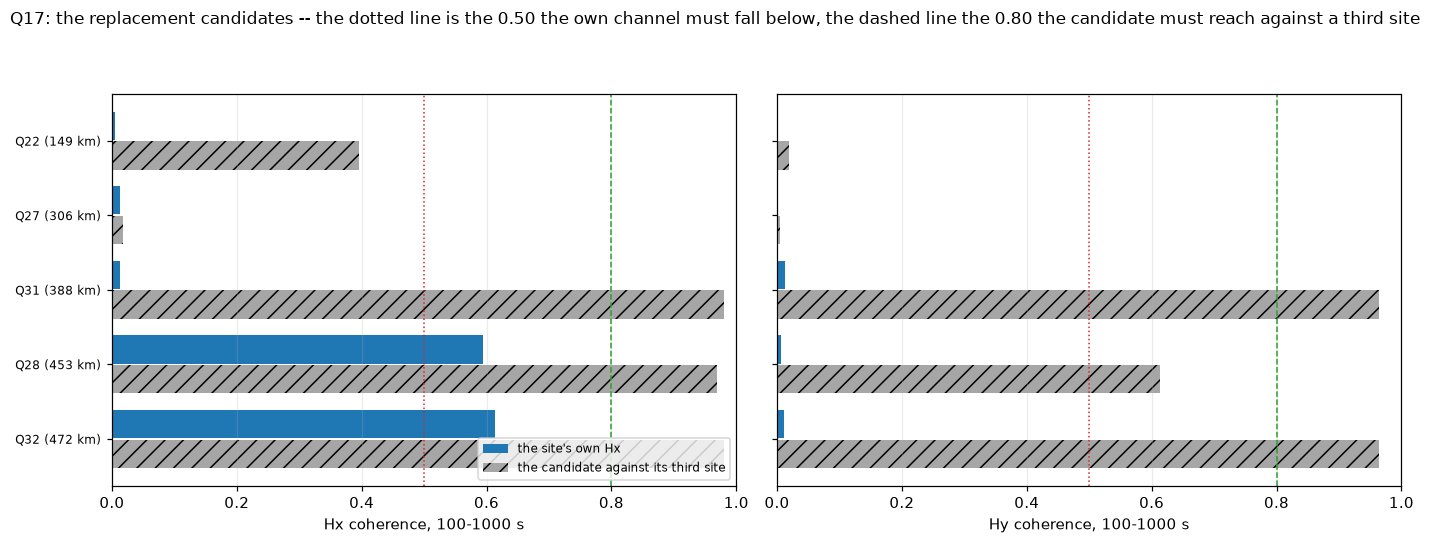

In [40]:
t = time.time()
_t0r, _hr, ANGLE, _nr = RP.rotated_pair(sv, SITE, 1)
ANGLE = FM.mean_angle(ANGLE)
try:
    _a, _b, _c, REF_INFO = REF.load_reference(BASELINE_KIND, SITE, 1, WORK)
except Exception as exc:
    REF_INFO = {}
    print("no %s reference sidecar: %s" % (BASELINE_KIND, str(exc)[:110]))
IN_REF = RP.reference_members(REF_INFO)
CANDS = RP.candidates(sv, SITE, donors=SITES, max_donors=5, exclude=IN_REF)
print("the %s reference this pass reads is built from %s, and those sites cannot lend"
      % (KIND_WORD.get(BASELINE_KIND, BASELINE_KIND), ", ".join(IN_REF) or "nothing"))
print("the site's frame angle is %+.4f deg" % ANGLE)
print(CANDS.round(3).to_string(index=False) if len(CANDS)
      else "no candidate covers %g days of the record" % RP.MIN_OVERLAP_DAYS)
print("(the candidates table took %.0f s)" % (time.time() - t))
fig = FF.candidate_bars(CANDS, SITE, OUT / "23_candidates.png", threshold=RP.SUB_THRESHOLD,
                        donor_gate=RP.DONOR_GATE)
WRITTEN.append(OUT / "23_candidates.png")
display(Image(filename=str(OUT / "23_candidates.png")))


In [41]:
CHAN, LEND = REPLACE_CHANNEL, LENDER
if len(CANDS):
    if CHAN is None:
        fired = CANDS[CANDS.rule_fires]
        CHAN = str((fired if len(fired) else CANDS).worst_channel.iloc[0])
    if LEND is None:
        ok = CANDS[CANDS.donor_sound] if CANDS.donor_sound.any() else CANDS
        LEND = str(ok.candidate.iloc[0])
NEEDED = bool(len(CANDS) and CANDS.rule_fires.any())
print("the substitution rule fires at %s: %s"
      % (SITE, "yes" if NEEDED else "no -- the site needs no replacement, and form B below is a "
         "demonstration on the channel the rule would pick"))
print("channel %s, lender %s%s" % (CHAN, LEND, "" if NEEDED else " (demonstration)"))


the substitution rule fires at Q17: yes
channel Hy, lender Q31


In [42]:
REPLACED = []
if LEND and CHAN:
    t0l, hl, _angl, _nl = RP.rotated_pair(sv, LEND, 1)
    lend_pair = RP.on_grid(hl, t0l, t0_rec, n_rec)
    _t0b, local_b, _ang_b, _ap, _un = FM.load_local(sv, SITE, 1)
    b = RP.replace_channel(local_b, lend_pair, CHAN, ANGLE)
    print("form B: %s" % b["note"])
    REPLACED.append(dict(name="replace_%s_%s" % (CHAN, LEND), spec=b, shown_only=False, lender=LEND,
                         kind=BASELINE_KIND,
                         why="scored per decade against the own-H baseline, the worst decade governing"))
    d = RP.replace_channel(local_b, lend_pair, CHAN, ANGLE, whole_pair=True)
    print("form D: %s" % d["note"])
    REPLACED.append(dict(name="lender_%s" % LEND, spec=d, shown_only=True, lender=LEND,
                         kind=BASELINE_KIND,
                         why="shown and never delivered: an inter-site impedance"))
    try:
        _st0, sh, smask, _si = REF.load_reference("stack", SITE, 1, WORK)
        stack_pair = {c: np.where(np.asarray(smask, bool)[:n_rec], np.asarray(sh[c], float)[:n_rec], np.nan)
                      for c in ("Hx", "Hy")}
        c_ = RP.replace_channel(local_b, stack_pair, CHAN, ANGLE)
        print("form C: %s, the channel taken from the fleet stack; its pass reads the observatory, because "
              "every member of the stack is inside its own local H" % c_["note"])
        REPLACED.append(dict(name="replace_%s_stack" % CHAN, spec=c_, shown_only=True, lender=None,
                             kind="obs",
                             why="shown and never delivered: a stack is a reference, never a local H"))
    except Exception as exc:
        print("form C: no fleet stack store for %s (%s)" % (SITE, str(exc)[:90]))
    del local_b, lend_pair
else:
    print("no candidate lender: no replacement form is built")


form B: Hy borrowed and turned into the site's sensor frame by R(+4.0674 deg); the site's own Hx kept in its mean-field frame; E and Hz own
form D: both horizontal channels borrowed and turned into the site's sensor frame by R(+4.0674 deg): the tensor of the site's E on the neighbour's field, an INTER-SITE IMPEDANCE, shown and never delivered
form C: Hy borrowed and turned into the site's sensor frame by R(+4.0674 deg); the site's own Hx kept in its mean-field frame; E and Hz own, the channel taken from the fleet stack; its pass reads the observatory, because every member of the stack is inside its own local H


In [43]:
for item in REPLACED:
    r = form(item["name"], kind=item["kind"], local_h=item["spec"]["arrays"],
             correction=item["spec"]["correction"], lender=item["lender"], criterion=item["why"],
             extra_lines=["h_replacement=%s" % item["spec"]["note"],
                          "h_basis_correction_is_a_rotation=%s" % item["spec"]["is_rotation"]])
    r["inter_site"] = bool(item["shown_only"] or item["spec"]["inter_site"])
    r["borrowed"] = "Hx+Hy" if all(item["spec"]["borrowed"]) else (CHAN or "")


In [44]:
rows = []
for item in REPLACED:
    r = made_product(item["name"])
    if r is None:
        rows.append(dict(form=item["name"],
                         error=str(rows_by_form().get(item["name"], {}).get("error"))[:110]))
        continue
    tf = read(r["product"])
    worst = ""
    if BASE:
        per = AG.per_decade(read(BASE), tf, bands=[tuple(b) for b in DECADES])
        p = per[np.isfinite(per.rho_ratio)]
        if len(p):
            k = int(np.nanargmax(np.abs(np.log10(p.rho_ratio.values))))
            worst = "%s %s %.2f, %+.1f deg" % (p.band.iloc[k], p.component.iloc[k], p.rho_ratio.iloc[k],
                                               p.phase_diff_deg.iloc[k])
    rows.append(dict(form=item["name"], kind=item["kind"], borrowed=r.get("borrowed"),
                     delivered=not r.get("inter_site"), bar_xy=DL.bar(tf, "xy", *BAR_BAND),
                     bar_yx=DL.bar(tf, "yx", *BAR_BAND), worst_decade_against_A=worst,
                     correction_reads_back=(r.get("turn") or {}).get("ok"),
                     correction_element=(r.get("turn") or {}).get("max_element_rel")))
print(pd.DataFrame(rows).round(4).to_string(index=False) if rows else "no replacement form was built")


            form   kind borrowed  delivered  bar_xy  bar_yx      worst_decade_against_A  correction_reads_back  correction_element
  replace_Hy_Q31 remote       Hy       True  0.0073  0.0044 5-10 s yx 10.95, -143.0 deg                   True                 0.0
      lender_Q31 remote    Hx+Hy      False  0.0067  0.0070    5-10 s xy 0.02, +3.9 deg                   True                 0.0
replace_Hy_stack    obs       Hy      False  0.0079  0.0044   5-10 s xy 0.00, +87.4 deg                   True                 0.0


Forms A to D on one set of panels: A the own-H baseline in black, B the single borrowed channel,
C the stack's channel and D the whole borrowed pair, the two shown-only forms drawn dashed. What to look for
is B following A while D sits off it: a single borrowed channel is a measurement of the same field, and a
whole borrowed pair is the inter-site impedance, which is a different quantity and is never delivered.

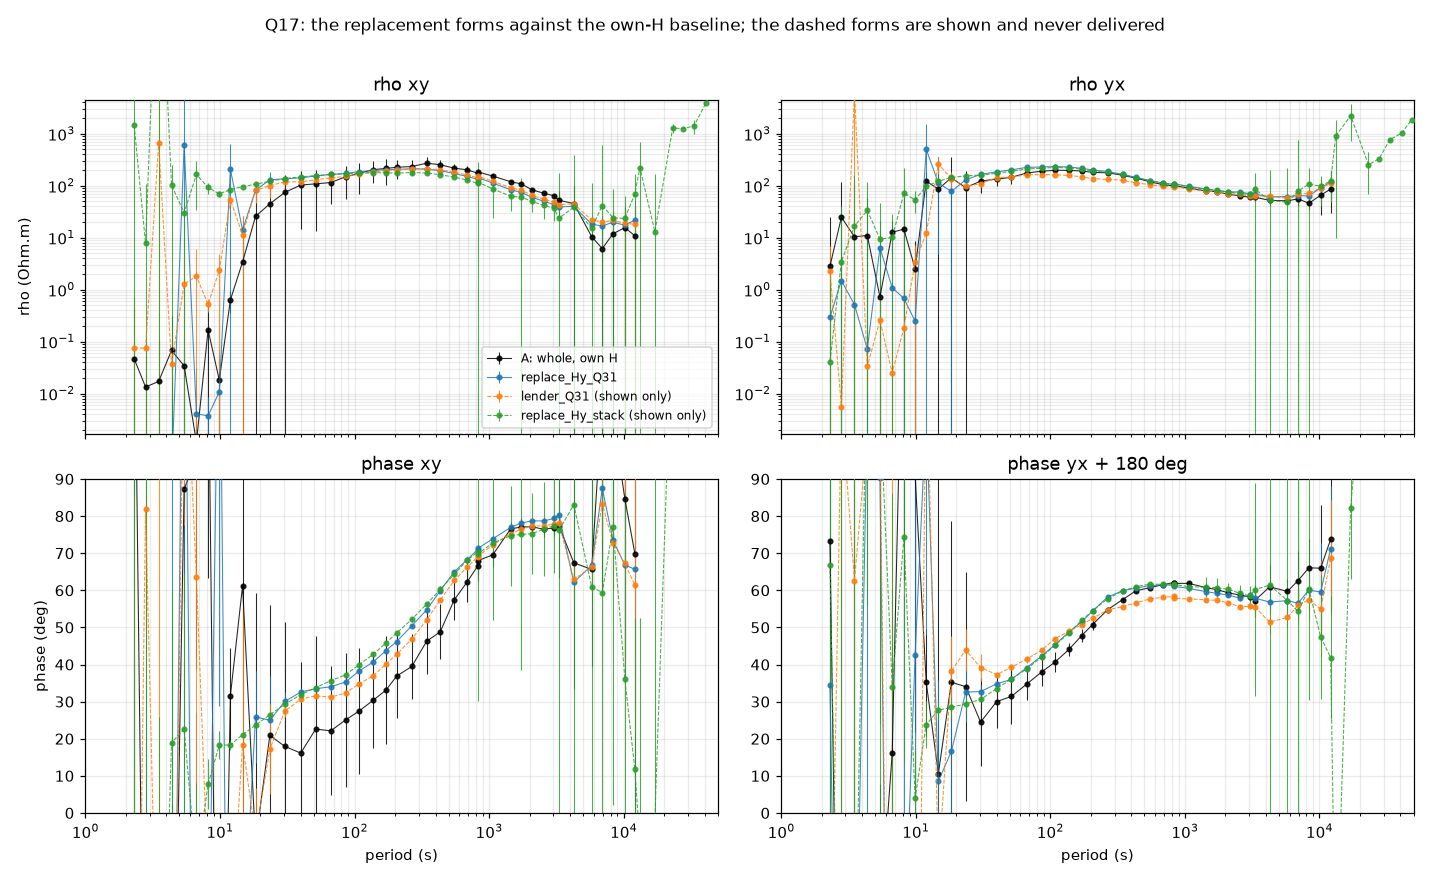

In [45]:
curves = [("A: whole, own H", read(BASE), "k", "-")] if BASE else []
for j, item in enumerate(REPLACED):
    r = made_product(item["name"])
    if r:
        curves.append(("%s%s" % (item["name"], " (shown only)" if item["shown_only"] else ""),
                       read(r["product"]), "C%d" % j, "--" if item["shown_only"] else "-"))
if len(curves) > 1:
    fig = FF.form_panels(curves, SITE, OUT / "22_forms_abcd.png",
                         title="%s: the replacement forms against the own-H baseline; the dashed forms are "
                               "shown and never delivered" % SITE, period_range=(1, 50000))
    WRITTEN.append(OUT / "22_forms_abcd.png")
    display(Image(filename=str(OUT / "22_forms_abcd.png")))
else:
    print("no replacement form was built, so there is nothing to draw against the baseline")


In [46]:
SPLICE = {}
b_name = "replace_%s_%s" % (CHAN, LEND) if (CHAN and LEND) else ""
r = made_product(b_name) if b_name else None
if BASE and r:
    a, b = read(BASE), read(r["product"])
    bg = AG.on_grid(a, b)
    for comp in ("xy", "yx"):
        ra, _ea, pa, _fa = PR.rho_phase(a.period, a.z, a.z_err, comp)
        rb, _eb, pb, _fb = PR.rho_phase(a.period, bg.z, bg.z_err, comp)
        SPLICE[comp] = RP.splice_period(a.period, rb, pb, ra, pa)
    print("the period from which the borrowed row stops costing, read against the own-H baseline:")
    for comp, s in SPLICE.items():
        print("   %s: t_c %s s over %d tested period(s), %.0f %% agreeing -- %s"
              % (comp, ("%.0f" % s["t_c"]) if np.isfinite(s["t_c"]) else "none", s["n_tested"],
                 100 * s["frac_agree"], s["rule"]))
    print("   below t_c the site's own short periods are kept and above it the borrowed row is delivered; a "
          "form with no t_c has no defensible splice and is not merged")
else:
    print("no single-channel replacement product to splice")


the period from which the borrowed row stops costing, read against the own-H baseline:
   xy: t_c none s over 25 tested period(s), 0 % agreeing -- within 5 % in rho and 5 deg in phase OR within 2 combined sigma, held to 3000 s
   yx: t_c none s over 25 tested period(s), 12 % agreeing -- within 5 % in rho and 5 deg in phase OR within 2 combined sigma, held to 3000 s
   below t_c the site's own short periods are kept and above it the borrowed row is delivered; a form with no t_c has no defensible splice and is not merged


In [47]:
fail = []
for item in REPLACED:
    r = rows_by_form().get(item["name"], {})
    if r.get("status") not in ("made", "exists"):
        if "lender" in str(r.get("error") or ""):
            fail.append("%s: %s" % (item["name"], r["error"]))
        continue
    if all(item["spec"]["borrowed"]) and not r.get("inter_site"):
        fail.append("%s borrows both horizontal channels and is not labelled an inter-site impedance"
                    % item["name"])
    t = r.get("turn") or {}
    if t and not t.get("ok"):
        fail.append("%s: the basis correction does not read back (elements %.2e, determinant %.2e)"
                    % (item["name"], t.get("max_element_rel", np.nan), t.get("max_det_scaled", np.nan)))
    if item["lender"] and item["lender"] in IN_REF:
        fail.append("the lender %s is a member of the %s reference %s reads"
                    % (item["lender"], item["kind"], item["name"]))
if not REPLACED:
    print("VERDICT: UNJUDGED -- no candidate lender was found, so no form was built and nothing was scored")
elif fail:
    print("VERDICT: FAIL -- %s" % "; ".join(fail))
else:
    print("VERDICT: PASS -- %d form(s) built; the lender %s is not a member of the %s reference (%s); every "
          "whole-pair form is labelled an inter-site impedance and is not delivered (%s); and every basis "
          "correction reads back to better than 1e-6 on the elements"
          % (len(REPLACED), LEND, BASELINE_KIND, ", ".join(IN_REF) or "no member",
             ", ".join(i["name"] for i in REPLACED if all(i["spec"]["borrowed"])) or "none built"))


VERDICT: PASS -- 3 form(s) built; the lender Q31 is not a member of the remote reference (Q21); every whole-pair form is labelled an inter-site impedance and is not delivered (lender_Q31); and every basis correction reads back to better than 1e-6 on the elements


## 9. The tipper-only delivery

The tipper is an H-only quantity and survives two dead electric lines, so a site with no deliverable
impedance can still deliver its tipper. The impedance rows are written as the empty-data fill and two INFO
lines say what the file is, so a reader cannot take the blank rows for a measurement.

The tipper is REFUSED where the vertical channel is not measuring the vertical field, and neither fault is
visible in the tipper itself: Hz a COPY of a horizontal channel, which reads a coherence of 1.00 with Hx and
makes the tipper a re-statement of the horizontal record, or a LEAK, where Hz carries the site's own
horizontal field at 1000-4000 s while carrying nothing of a neighbour's vertical field. A real vertical field
is coherent with a neighbour's at those periods, because the source is regional.

This section is a reading and not a check: it applies where both lines are dead, or on demand.

In [48]:
TIP = DL.tipper_refusal(sv, SITE)
print("Hz with its own Hx %.3f (a copy at or above %.2f); with its own H %.3f (a leak at or above %.2f) "
      "while with %s's Hz %.3f (under %.2f)"
      % (TIP.get("coh_hz_hx", np.nan), DL.COPY_COH, TIP.get("coh_hz_own_h", np.nan), DL.LEAK_OWN_COH,
         TIP.get("neighbour"), TIP.get("coh_hz_neighbour_hz", np.nan), DL.LEAK_NEIGHBOUR_COH))
print("the refusal test: %s -- %s" % ("REFUSED" if TIP.get("refused") else "the tipper stands",
                                      TIP.get("reason")))
dead_lines = [c for c in COMPONENTS
              if len(ELINES) and (ELINES["%s_state" % LINE[c]] == "dead").mean() > 0.5]
if BASE and (len(dead_lines) == len(COMPONENTS) or TIP.get("refused")):
    out = OUT / FM.product_name(SITE, "tipper_only", BASELINE_KIND, 1, PARAMS)
    got = DL.tipper_only(BASE, out, KIND_WORD.get(BASELINE_KIND, BASELINE_KIND), TIP)
    print(got)
    if got.get("written"):
        FORM_ROWS.append(dict(site=SITE, form="tipper_only", kind=BASELINE_KIND, rate_hz=1.0, params=PARAMS,
                              product=str(out), controls="", seed=None, status="made",
                              criterion="an H-only delivery; the impedance rows carry no product of record",
                              error="", days=None, n_runs=None, seconds=None))
else:
    print("neither line is dead on most days (%s) and the tipper is not refused, so the tipper-only "
          "delivery does not apply here: the tipper ships inside the impedance products"
          % (", ".join(dead_lines) or "no line dead"))


Hz with its own Hx 0.611 (a copy at or above 0.99); with its own H 0.611 (a leak at or above 0.95) while with Q21's Hz nan (under 0.10)
the refusal test: the tipper stands -- neither fault fires
neither line is dead on most days (no line dead) and the tipper is not refused, so the tipper-only delivery does not apply here: the tipper ships inside the impedance products


## 10. The forms table

Every form with the products it is read against, the criterion in words, the verdict and the reading. This is
the file workbook 06 reads. A form is a CANDIDATE only where it beats every control it carries on the
10-1000 s bar by BAR_MARGIN: a selection whose product does not beat its random control buys efficiency, not
a different answer, and is not promoted. A form with no control is read and never promoted on this table
alone, and a form that borrows both horizontal channels is never a candidate.

The decisions.csv cells this workbook proposes are printed below and are NOT written unless WRITE_DECISIONS
is True. Decisions are the analyst's.

In [49]:
TABLE = DL.forms_table(FORM_ROWS, OUT / "forms.csv", baseline_path=BASE, bar_band=tuple(BAR_BAND),
                       agree_band=tuple(AGREE_BAND), margin=BAR_MARGIN)
WRITTEN.append(OUT / "forms.csv")
cols = ["form", "kind", "rate_hz", "status", "controls", "bar_10_1000", "control_bar", "rho_ratio_xy",
        "phase_diff_xy", "rho_ratio_yx", "phase_diff_yx", "verdict", "candidate"]
print(TABLE[cols].round(4).to_string(index=False))
print()
print("%d form(s), %d made, %d candidate(s) for workbook 06: %s"
      % (len(TABLE), int((TABLE.status == "made").sum()), int(TABLE.candidate.sum()),
         " ".join(TABLE[TABLE.candidate].form) or "none"))
FM.write_run_provenance(sv, SITE, OUT, RUN, OUT.name.split("_", 1)[-1], 1, PARAMS, BASELINE_KIND, FORM_ROWS)
print("provenance.json rewritten with %d form entries" % len(FORM_ROWS))


              form   kind  rate_hz status                          controls  bar_10_1000                                     control_bar  rho_ratio_xy  phase_diff_xy  rho_ratio_yx  phase_diff_yx                                                                                       verdict  candidate
             whole remote      1.0 exists                              none       0.0393                                                           NaN            NaN           NaN            NaN                                                  read, no control: not promoted on this table      False
        daymask_xy remote      1.0 exists                daymask_xy_control       0.0375                       daymask_xy_control 0.0765        0.9798        -0.3222        0.9930        -0.0069                                    beats its control(s) on the 10-1000 s bar by at least 20 %       True
daymask_xy_control remote      1.0 exists                              none       0.0765            

The same table as a figure: one bar per form on the 10-1000 s bar, its control marked as a red
diamond beside it, a candidate in green. What to look for is a green bar well to the left of its diamond --
that gap is the 20 per cent margin -- and how many forms sit on top of the baseline, which is the reading
that the record was already being used for what it is worth.

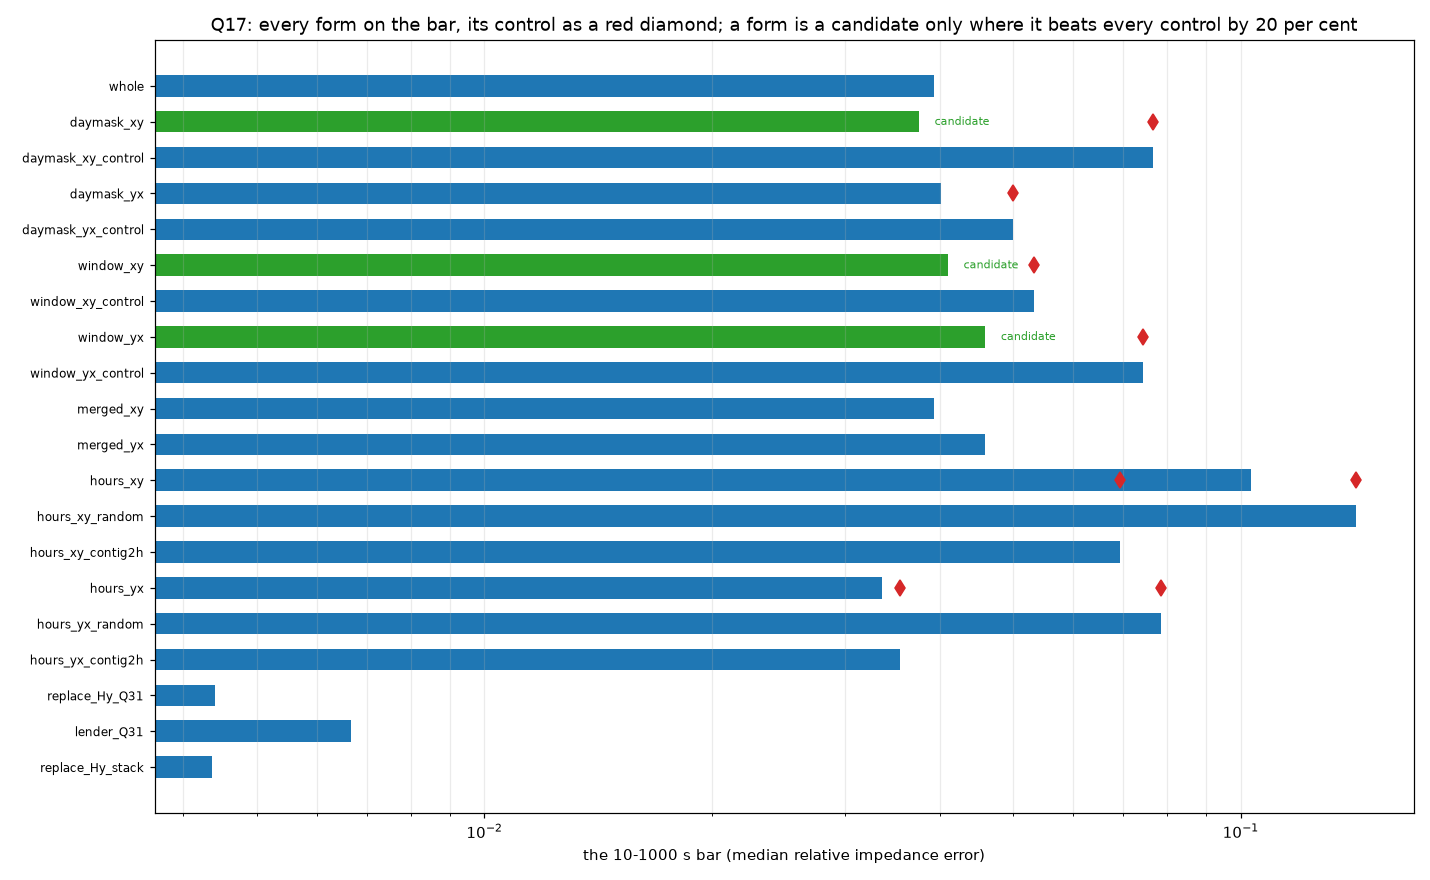

In [50]:
fig = FF.forms_bars(TABLE, SITE, OUT / "24_forms_bars.png", band=tuple(BAR_BAND), margin=BAR_MARGIN)
WRITTEN.append(OUT / "24_forms_bars.png")
display(Image(filename=str(OUT / "24_forms_bars.png")))


In [51]:
evidence = []
for c in COMPONENTS:
    bars = ";".join("%s %.4f" % (r.form, r.bar_10_1000) for r in TABLE.itertuples()
                    if str(r.form).startswith("window_%s" % c) and np.isfinite(r.bar_10_1000))
    evidence.append(dict(component=c, fraction=HOURS_FRACTION, record_days=round(n_rec / 86400.0, 2),
                         in_use=False,
                         evidence="control: an equal-length random block, seed %d; %g-%g s bar %s"
                                  % (WINDOWS[c]["seed"], BAR_BAND[0], BAR_BAND[1], bars or "not scored")))
WIN_TABLE = MK.windows_table(SITE, OUT.name, WINDOWS, evidence)
WIN_TABLE.to_csv(SITE_DIR / "windows.csv", index=False)
WRITTEN.append(SITE_DIR / "windows.csv")
print(WIN_TABLE.to_string(index=False))
print()
proposed = MK.write_windows(SV.blank_decisions([SITE]), SITE, WINDOWS)
flags = []
me = CENTRE.get(SITE, {})
if me.get("model_holds"):
    flags.append("shared centre: residual coherence %.2f, gain %.2f, s %+d; the remedy %s"
                 % (me["resid_coh"], me["resid_gain"], me["s_obs"],
                    "applies" if me["remedy_applicable"] else
                    "does NOT apply (the clean diagonal by H is the %s and the observed one is the %s)"
                    % (me["clean_by_H"], me["clean_obs"])))
if NOTCH.get("fired"):
    flags.append("notch: %s" % ", ".join(NOTCH["fired"]))
if NEEDED:
    flags.append("magnetic replacement: %s from %s" % (CHAN, LEND))
proposed.loc[proposed.site == SITE, "flags"] = "; ".join(flags) or "decide"
print("the decisions.csv cells this workbook proposes for %s" % SITE)
print(proposed[["site", "windows", "flags"]].to_string(index=False))
if WRITE_DECISIONS:
    path = SV.SURVEYS / SURVEY / "decisions.csv"
    cur = sv.decisions.copy()
    for col in ("windows", "flags"):
        cur.loc[cur.site == SITE, col] = proposed[col].iloc[0]
    print(SV.write_table(path, cur, SV.DECISIONS_COLUMNS))
else:
    print("NOT written: WRITE_DECISIONS is False, and decisions are the analyst's")


site                run channel arm component    t_start      t_end  days  fraction  n_live_days  record_days  in_use                                                                                                                                                                                                                                                                                                                   rule
 Q17 site_20260916_2022      Ex            xy 2026-07-08 2026-07-15   7.0      0.25            7        34.03   False the longest run of sound+weak days of Ex: 7 day(s), 2026-07-08 to 2026-07-15; no run of sound days reaches the 0.50 d floor, so the weak days are admitted and the window is a proposal, not a finding | control: an equal-length random block, seed 20260916; 10-1000 s bar window_xy 0.0410;window_xy_control 0.0533
 Q17 site_20260916_2022      Ey            yx 2026-07-08 2026-07-14   6.0      0.25            6        34.03   False                         

## 11. What was written

In [52]:
rows = []
for p in list(WRITTEN) + sorted(OUT.glob("*")):
    p = Path(p)
    if p.exists() and p.is_file():
        rows.append(dict(file=str(p), kb=round(p.stat().st_size / 1024, 1)))
files = pd.DataFrame(rows).drop_duplicates("file").sort_values("file")
print("%d file(s), %.1f MB, in %.1f minutes" % (len(files), files.kb.sum() / 1024, (time.time() - T0) / 60))
print(files.to_string(index=False))
print()
cost = pd.DataFrame([dict(form=r.get("form"), rate_hz=r.get("rate_hz"), status=r.get("status"),
                          days=r.get("days"), runs=r.get("n_runs"), seconds=r.get("seconds"),
                          error=str(r.get("error") or "")[:60]) for r in FORM_ROWS])
print("the forms and what each cost")
print(cost.to_string(index=False))


55 file(s), 3.9 MB, in 1.1 minutes
                                                                                                                              file    kb
                           E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\06_daily_magnetics.png  64.8
                                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\07_fleet.png  95.0
                                     E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\08_clock.png  80.6
                               E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\09_quality_map.png  97.2
                                 E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\10_day_masks.png 158.2
                          E:\MT_Timeseries_DATA\MT_AusLAMP_QLD\Processing_WB\phase3\Q17\site_20260916_2022\11_daymask_products.png 293.5
      